# Gaussian Mixture Model Evaluation  
## Components 2 to 10 using the final seven-feature customer dataset

### Purpose

This notebook evaluates Gaussian Mixture Model configurations before a final
five-component GMM is trained.

It uses exactly the same:

- 4,338 customers;
- seven processed behavioural features;
- feature order;
- original-scale profile dataset;

as the frozen K-Means analysis.

The notebook evaluates:

1. component counts from 2 to 10;
2. full, tied, diagonal and spherical covariance structures;
3. GMM-specific model-selection measures:
   - Bayesian Information Criterion;
   - Akaike Information Criterion;
   - average log-likelihood;
4. common clustering measures:
   - Silhouette Score;
   - Davies–Bouldin Index;
   - Calinski–Harabasz Index;
5. convergence and numerical health;
6. component-size feasibility;
7. summary membership uncertainty;
8. random-seed stability for shortlisted configurations;
9. repeated 80% subsampling stability for shortlisted configurations;
10. original-scale mean and median profiles.



## Notebook outputs

The notebook creates:

- a complete 36-configuration GMM evaluation table;
- AIC and BIC comparison tables;
- common validation results;
- convergence and component-size evidence;
- candidate seed-stability results;
- candidate subsampling-stability results;
- candidate original-scale profiles;
- saved baseline GMM models;
- candidate assignment datasets;
- visual comparison figures;
- a ZIP archive containing all outputs.

## 1. Import libraries

In [ ]:
import os
import json
import time
import shutil
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure files, features and GMM evaluation settings

Upload these two files to the Colab Files panel:

- `customer_features_processed.csv`
- `customer_features_ready_for_preprocessing.csv`

The processed dataset is used to fit GMM. The original-scale dataset is used
only for interpretation and profiles.

In [ ]:
PROCESSED_FILE = (
    "/content/customer_features_processed.csv"
)

ORIGINAL_SCALE_FILE = (
    "/content/"
    "customer_features_ready_for_preprocessing.csv"
)

RESULTS_DIR = Path(
    "/content/GMM_Evaluation_Components_2_to_10_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
MODELS_DIR = RESULTS_DIR / "Models"
ASSIGNMENTS_DIR = RESULTS_DIR / "Assignments"
PROFILES_DIR = RESULTS_DIR / "Profiles"
STABILITY_DIR = RESULTS_DIR / "Stability"
CANDIDATE_DIR = RESULTS_DIR / "Candidate_Review"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    ASSIGNMENTS_DIR,
    PROFILES_DIR,
    STABILITY_DIR,
    CANDIDATE_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

COMPONENT_VALUES = list(
    range(2, 11)
)

COVARIANCE_TYPES = [
    "full",
    "tied",
    "diag",
    "spherical"
]

BASELINE_RANDOM_STATE = 42
GRID_N_INIT = 10
GRID_MAX_ITER = 500
TOLERANCE = 1e-3
REGULARISATION = 1e-5
INITIALISATION = "kmeans"

MINIMUM_COMPONENT_PERCENTAGE = 5.0

# Stability is applied only to automatically shortlisted configurations.
SEED_STABILITY_RUNS = 20
SUBSAMPLE_STABILITY_RUNS = 30
SUBSAMPLE_FRACTION = 0.80
STABILITY_N_INIT = 10
STABILITY_RANDOM_STATE = 2026

# Summary probability conditions used only for model-selection evidence.
LOW_MAX_PROBABILITY_THRESHOLD = 0.60
LOW_PROBABILITY_MARGIN_THRESHOLD = 0.20

print("Component values:", COMPONENT_VALUES)
print("Covariance structures:", COVARIANCE_TYPES)
print("Output folder:", RESULTS_DIR)

Component values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Covariance structures: ['full', 'tied', 'diag', 'spherical']
Output folder: /content/GMM_Evaluation_Components_2_to_10_Results


## 3. Load the processed and original-scale customer datasets

In [ ]:
if not os.path.exists(PROCESSED_FILE):
    raise FileNotFoundError(
        f"Processed dataset not found: {PROCESSED_FILE}"
    )

if not os.path.exists(ORIGINAL_SCALE_FILE):
    raise FileNotFoundError(
        "Original-scale customer feature dataset not found: "
        f"{ORIGINAL_SCALE_FILE}"
    )

processed_data = pd.read_csv(
    PROCESSED_FILE
)

original_scale_data = pd.read_csv(
    ORIGINAL_SCALE_FILE
)

print("=" * 80)
print("DATASETS LOADED")
print("=" * 80)

print(
    "Processed dataset shape:",
    processed_data.shape
)

print(
    "Original-scale dataset shape:",
    original_scale_data.shape
)

display(processed_data.head())
display(original_scale_data.head())

DATASETS LOADED
Processed dataset shape: (4338, 8)
Original-scale dataset shape: (4338, 9)


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,"77,183.6000",74215,1,1,"77,183.6000","74,215.0000"
1,12347,2,7,"4,310.0000",2458,103,182,615.7100,351.1400
2,12348,75,4,"1,797.2400",2341,22,31,449.3100,585.2500
3,12349,19,1,"1,757.5500",631,73,73,"1,757.5500",631.0000
4,12350,310,1,334.4000,197,17,17,334.4000,197.0000


## 4. Validate and align the customer datasets

In [ ]:
REQUIRED_COLUMNS = [
    "CustomerID"
] + FEATURE_COLUMNS

missing_processed = [
    column
    for column in REQUIRED_COLUMNS
    if column not in processed_data.columns
]

missing_original = [
    column
    for column in REQUIRED_COLUMNS
    if column not in original_scale_data.columns
]

if missing_processed:
    raise ValueError(
        "Missing columns in processed data: "
        f"{missing_processed}"
    )

if missing_original:
    raise ValueError(
        "Missing columns in original-scale data: "
        f"{missing_original}"
    )

if processed_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values found in processed data."
    )

if original_scale_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values found in original-scale data."
    )

if processed_data[REQUIRED_COLUMNS].isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in processed clustering data."
    )

if original_scale_data[REQUIRED_COLUMNS].isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in original-scale data."
    )

original_scale_data = (
    processed_data[["CustomerID"]]
    .merge(
        original_scale_data[
            REQUIRED_COLUMNS
        ],
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

if original_scale_data.isnull().sum().sum() > 0:
    raise ValueError(
        "Customer alignment failed."
    )

if not np.array_equal(
    processed_data["CustomerID"].to_numpy(),
    original_scale_data["CustomerID"].to_numpy()
):
    raise ValueError(
        "Customer ordering differs between the two datasets."
    )

X = processed_data[
    FEATURE_COLUMNS
].copy()

if not np.isfinite(
    X.to_numpy()
).all():
    raise ValueError(
        "Infinite or non-finite values found in X."
    )

EXPECTED_CUSTOMERS = 4338

if len(X) != EXPECTED_CUSTOMERS:
    raise ValueError(
        "The GMM comparison must use the frozen customer "
        f"population of {EXPECTED_CUSTOMERS:,}. "
        f"Current rows: {len(X):,}"
    )

if X.shape[1] != 7:
    raise ValueError(
        "The GMM comparison must use exactly seven features."
    )

print("=" * 80)
print("INPUT VALIDATION COMPLETED")
print("=" * 80)

print("Customers:", len(X))
print("Features:", len(FEATURE_COLUMNS))
print("Feature order:", FEATURE_COLUMNS)

display(X.describe().T)

INPUT VALIDATION COMPLETED
Customers: 4338
Features: 7
Feature order: ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.0000",0.3350,0.8066,-0.4032,-0.2661,0.0000,0.7339,2.6048
Frequency,"4,338.0000",0.2248,0.6218,-0.3691,-0.3691,0.0000,0.6309,3.8671
Monetary,"4,338.0000",0.0486,0.7459,-2.9331,-0.4613,-0.0000,0.5387,3.5781
AverageOrderValue,"4,338.0000",-0.0388,0.8516,-4.7825,-0.5635,0.0000,0.4365,6.4666
BasketSize,"4,338.0000",-0.0439,0.8450,-4.1088,-0.5189,0.0000,0.4811,5.7289
ProductDiversity,"4,338.0000",-0.0210,0.7427,-1.8972,-0.4925,0.0000,0.5075,2.5634
TotalQuantity,"4,338.0000",0.0239,0.7517,-2.8763,-0.4730,0.0000,0.5270,3.4295


In [ ]:
excluded_columns = [
    column
    for column in processed_data.columns
    if column not in [
        "CustomerID"
    ] + FEATURE_COLUMNS
]

excluded_columns_report = pd.DataFrame({
    "Excluded_Column": excluded_columns,
    "Reason": [
        (
            "Not included in the frozen seven-feature "
            "clustering matrix."
        )
        for _ in excluded_columns
    ]
})

display(excluded_columns_report)

excluded_columns_report.to_csv(
    TABLES_DIR / "excluded_columns_report.csv",
    index=False
)

,Excluded_Column,Reason


## 6. Create a common PCA visualisation space

PCA is used only for two-dimensional figures. Every GMM model is fitted to
the full seven-feature processed matrix.

In [ ]:
pca = PCA(
    n_components=2,
    random_state=BASELINE_RANDOM_STATE
)

pca_coordinates = pca.fit_transform(X)

pca_data = pd.DataFrame({
    "CustomerID": processed_data["CustomerID"],
    "PC1": pca_coordinates[:, 0],
    "PC2": pca_coordinates[:, 1]
})

pca_summary = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_Variance_Ratio": (
        pca.explained_variance_ratio_
    ),
    "Explained_Variance_Percentage": (
        pca.explained_variance_ratio_ * 100
    )
})

display(pca_summary)

pca_summary.to_csv(
    TABLES_DIR / "pca_explained_variance.csv",
    index=False
)

joblib.dump(
    pca,
    MODELS_DIR / "gmm_evaluation_pca_visualisation.joblib"
)

,Component,Explained_Variance_Ratio,Explained_Variance_Percentage
0,PC1,0.6156,61.5640
1,PC2,0.1980,19.8007


['/content/GMM_Evaluation_Components_2_to_10_Results/Models/gmm_evaluation_pca_visualisation.joblib']

## 7. Define helper functions

In [ ]:
def build_gmm(
    n_components,
    covariance_type,
    random_state,
    n_init=GRID_N_INIT
):
    return GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        tol=TOLERANCE,
        reg_covar=REGULARISATION,
        max_iter=GRID_MAX_ITER,
        n_init=n_init,
        init_params=INITIALISATION,
        random_state=random_state
    )


def create_component_size_table(
    labels,
    n_components
):
    table = (
        pd.Series(
            labels,
            name="Component"
        )
        .value_counts()
        .sort_index()
        .reindex(
            range(n_components),
            fill_value=0
        )
        .rename_axis("Component")
        .reset_index(
            name="Customer_Count"
        )
    )

    table["Customer_Percentage"] = (
        table["Customer_Count"]
        / table["Customer_Count"].sum()
        * 100
    )

    return table


def normalised_entropy(probabilities):
    clipped = np.clip(
        probabilities,
        1e-15,
        1.0
    )

    entropy = -np.sum(
        clipped * np.log(clipped),
        axis=1
    )

    return entropy / np.log(
        probabilities.shape[1]
    )


def minimum_covariance_value(
    fitted_model
):
    covariance_type = (
        fitted_model.covariance_type
    )

    covariance = (
        fitted_model.covariances_
    )

    if covariance_type == "full":
        return float(
            min(
                np.linalg.eigvalsh(
                    matrix
                ).min()
                for matrix in covariance
            )
        )

    if covariance_type == "tied":
        return float(
            np.linalg.eigvalsh(
                covariance
            ).min()
        )

    return float(
        np.min(covariance)
    )


def configuration_name(
    n_components,
    covariance_type
):
    return (
        f"GMM_C{n_components}_"
        f"{covariance_type}"
    )

## 8. Evaluate the complete GMM grid

The full grid contains:

\[
9\ 	ext{component counts}
	imes
4\ 	ext{covariance structures}
=
36\ 	ext{configurations}
\]

For every successful configuration, the notebook saves:

- the fitted model;
- hard component assignments;
- maximum and second-highest membership probabilities;
- probability margin;
- normalised entropy;
- component sizes;
- original-scale mean and median profiles;
- AIC, BIC and log-likelihood;
- common clustering metrics;
- convergence information.

In [ ]:
grid_results = []
failed_configurations = []

models_by_configuration = {}
labels_by_configuration = {}
probabilities_by_configuration = {}
mean_profiles_by_configuration = {}
median_profiles_by_configuration = {}

for covariance_type in COVARIANCE_TYPES:

    for n_components in COMPONENT_VALUES:

        config_name = configuration_name(
            n_components,
            covariance_type
        )

        print("\n" + "=" * 90)
        print(
            "FITTING",
            config_name
        )
        print("=" * 90)

        start_time = time.perf_counter()

        try:
            model = build_gmm(
                n_components=n_components,
                covariance_type=covariance_type,
                random_state=BASELINE_RANDOM_STATE
            )

            labels = model.fit_predict(X)

            elapsed_seconds = (
                time.perf_counter()
                - start_time
            )

            unique_components = np.unique(
                labels
            )

            if len(unique_components) < 2:
                raise ValueError(
                    "The fitted model produced fewer than "
                    "two populated components."
                )

            probabilities = model.predict_proba(X)

            sorted_probabilities = np.sort(
                probabilities,
                axis=1
            )

            maximum_probability = (
                sorted_probabilities[:, -1]
            )

            second_probability = (
                sorted_probabilities[:, -2]
            )

            probability_margin = (
                maximum_probability
                - second_probability
            )

            customer_entropy = (
                normalised_entropy(
                    probabilities
                )
            )

            silhouette = silhouette_score(
                X,
                labels
            )

            dbi = davies_bouldin_score(
                X,
                labels
            )

            ch = calinski_harabasz_score(
                X,
                labels
            )

            component_sizes = (
                create_component_size_table(
                    labels,
                    n_components
                )
            )

            smallest_component_percentage = float(
                component_sizes[
                    "Customer_Percentage"
                ].min()
            )

            empty_component_count = int(
                (
                    component_sizes[
                        "Customer_Count"
                    ] == 0
                ).sum()
            )

            assignment_data = pd.DataFrame({
                "CustomerID": (
                    processed_data[
                        "CustomerID"
                    ]
                ),
                "Component": labels,
                "Maximum_Probability": (
                    maximum_probability
                ),
                "Second_Probability": (
                    second_probability
                ),
                "Probability_Margin": (
                    probability_margin
                ),
                "Normalised_Entropy": (
                    customer_entropy
                )
            })

            assignment_data.to_csv(
                ASSIGNMENTS_DIR
                / f"{config_name}_assignments.csv",
                index=False
            )

            original_clustered = (
                original_scale_data.copy()
            )

            original_clustered[
                "Component"
            ] = labels

            mean_profile = (
                original_clustered
                .groupby(
                    "Component"
                )[FEATURE_COLUMNS]
                .mean()
                .round(4)
            )

            median_profile = (
                original_clustered
                .groupby(
                    "Component"
                )[FEATURE_COLUMNS]
                .median()
                .round(4)
            )

            mean_profile.to_csv(
                PROFILES_DIR
                / f"{config_name}_mean_profile.csv"
            )

            median_profile.to_csv(
                PROFILES_DIR
                / f"{config_name}_median_profile.csv"
            )

            component_sizes.to_csv(
                TABLES_DIR
                / f"{config_name}_component_sizes.csv",
                index=False
            )

            joblib.dump(
                model,
                MODELS_DIR
                / f"{config_name}.joblib"
            )

            grid_results.append({
                "Configuration": config_name,
                "N_Components": n_components,
                "Covariance_Type": covariance_type,
                "Converged": bool(
                    model.converged_
                ),
                "Iterations": int(
                    model.n_iter_
                ),
                "Fit_Time_Seconds": elapsed_seconds,
                "Average_Log_Likelihood": float(
                    model.score(X)
                ),
                "Lower_Bound": float(
                    model.lower_bound_
                ),
                "AIC": float(
                    model.aic(X)
                ),
                "BIC": float(
                    model.bic(X)
                ),
                "Silhouette_Score": float(
                    silhouette
                ),
                "Davies_Bouldin_Index": float(
                    dbi
                ),
                "Calinski_Harabasz_Index": float(
                    ch
                ),
                "Smallest_Component_Count": int(
                    component_sizes[
                        "Customer_Count"
                    ].min()
                ),
                "Largest_Component_Count": int(
                    component_sizes[
                        "Customer_Count"
                    ].max()
                ),
                "Smallest_Component_Percentage": (
                    smallest_component_percentage
                ),
                "Largest_Component_Percentage": float(
                    component_sizes[
                        "Customer_Percentage"
                    ].max()
                ),
                "Empty_Component_Count": (
                    empty_component_count
                ),
                "All_Components_At_Least_5_Percent": bool(
                    smallest_component_percentage
                    >= MINIMUM_COMPONENT_PERCENTAGE
                ),
                "Mean_Maximum_Probability": float(
                    maximum_probability.mean()
                ),
                "Median_Maximum_Probability": float(
                    np.median(
                        maximum_probability
                    )
                ),
                "Low_Maximum_Probability_Count": int(
                    (
                        maximum_probability
                        < LOW_MAX_PROBABILITY_THRESHOLD
                    ).sum()
                ),
                "Low_Maximum_Probability_Percentage": float(
                    (
                        maximum_probability
                        < LOW_MAX_PROBABILITY_THRESHOLD
                    ).mean()
                    * 100
                ),
                "Mean_Probability_Margin": float(
                    probability_margin.mean()
                ),
                "Median_Probability_Margin": float(
                    np.median(
                        probability_margin
                    )
                ),
                "Low_Probability_Margin_Count": int(
                    (
                        probability_margin
                        < LOW_PROBABILITY_MARGIN_THRESHOLD
                    ).sum()
                ),
                "Low_Probability_Margin_Percentage": float(
                    (
                        probability_margin
                        < LOW_PROBABILITY_MARGIN_THRESHOLD
                    ).mean()
                    * 100
                ),
                "Mean_Normalised_Entropy": float(
                    customer_entropy.mean()
                ),
                "Maximum_Normalised_Entropy": float(
                    customer_entropy.max()
                ),
                "Minimum_Covariance_Value": (
                    minimum_covariance_value(
                        model
                    )
                )
            })

            models_by_configuration[
                config_name
            ] = model

            labels_by_configuration[
                config_name
            ] = labels

            probabilities_by_configuration[
                config_name
            ] = probabilities

            mean_profiles_by_configuration[
                config_name
            ] = mean_profile

            median_profiles_by_configuration[
                config_name
            ] = median_profile

            print(
                f"Completed {config_name} | "
                f"BIC={model.bic(X):,.2f} | "
                f"Silhouette={silhouette:.4f} | "
                f"Converged={model.converged_}"
            )

        except Exception as error:

            elapsed_seconds = (
                time.perf_counter()
                - start_time
            )

            failed_configurations.append({
                "Configuration": config_name,
                "N_Components": n_components,
                "Covariance_Type": covariance_type,
                "Elapsed_Seconds": elapsed_seconds,
                "Error_Type": type(error).__name__,
                "Error_Message": str(error)
            })

            print(
                f"FAILED: {config_name}"
            )
            print(
                type(error).__name__,
                str(error)
            )


FITTING GMM_C2_full
Completed GMM_C2_full | BIC=-28,020.29 | Silhouette=0.2322 | Converged=True

FITTING GMM_C3_full
Completed GMM_C3_full | BIC=-44,939.92 | Silhouette=0.1187 | Converged=True

FITTING GMM_C4_full
Completed GMM_C4_full | BIC=-48,039.59 | Silhouette=0.0991 | Converged=True

FITTING GMM_C5_full
Completed GMM_C5_full | BIC=-51,802.49 | Silhouette=0.0574 | Converged=True

FITTING GMM_C6_full
Completed GMM_C6_full | BIC=-61,786.32 | Silhouette=0.0237 | Converged=True

FITTING GMM_C7_full
Completed GMM_C7_full | BIC=-62,355.07 | Silhouette=0.0105 | Converged=True

FITTING GMM_C8_full
Completed GMM_C8_full | BIC=-61,908.31 | Silhouette=-0.0018 | Converged=True

FITTING GMM_C9_full
Completed GMM_C9_full | BIC=-62,787.01 | Silhouette=-0.0027 | Converged=True

FITTING GMM_C10_full
Completed GMM_C10_full | BIC=-63,232.71 | Silhouette=-0.0233 | Converged=True

FITTING GMM_C2_tied
Completed GMM_C2_tied | BIC=-12,785.58 | Silhouette=0.2153 | Converged=True

FITTING GMM_C3_tied
Comp

## 9. Create and rank the complete evaluation table

In [ ]:
grid_results_df = (
    pd.DataFrame(
        grid_results
    )
    .sort_values(
        [
            "Covariance_Type",
            "N_Components"
        ]
    )
    .reset_index(drop=True)
)

failed_configurations_df = pd.DataFrame(
    failed_configurations
)

if grid_results_df.empty:
    raise RuntimeError(
        "No GMM configuration completed successfully."
    )

grid_results_df["AIC_Rank"] = (
    grid_results_df[
        "AIC"
    ]
    .rank(
        ascending=True,
        method="min"
    )
)

grid_results_df["BIC_Rank"] = (
    grid_results_df[
        "BIC"
    ]
    .rank(
        ascending=True,
        method="min"
    )
)

grid_results_df["Silhouette_Rank"] = (
    grid_results_df[
        "Silhouette_Score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

grid_results_df["Davies_Bouldin_Rank"] = (
    grid_results_df[
        "Davies_Bouldin_Index"
    ]
    .rank(
        ascending=True,
        method="min"
    )
)

grid_results_df[
    "Calinski_Harabasz_Rank"
] = (
    grid_results_df[
        "Calinski_Harabasz_Index"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

grid_results_df[
    "Average_Common_Validation_Rank"
] = (
    grid_results_df[
        [
            "Silhouette_Rank",
            "Davies_Bouldin_Rank",
            "Calinski_Harabasz_Rank"
        ]
    ]
    .mean(axis=1)
)

grid_results_df = (
    grid_results_df
    .round(6)
)

print("=" * 80)
print("COMPLETE GMM GRID RESULTS")
print("=" * 80)

display(grid_results_df)

if not failed_configurations_df.empty:
    print("\nFailed configurations:")
    display(failed_configurations_df)

grid_results_df.to_csv(
    TABLES_DIR / "gmm_complete_grid_evaluation.csv",
    index=False
)

failed_configurations_df.to_csv(
    TABLES_DIR / "gmm_failed_configurations.csv",
    index=False
)

COMPLETE GMM GRID RESULTS


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Largest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,Empty_Component_Count,All_Components_At_Least_5_Percent,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Maximum_Normalised_Entropy,Minimum_Covariance_Value,AIC_Rank,BIC_Rank,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Common_Validation_Rank
0,GMM_C2_diag,2,diag,True,7,0.1251,-6.5082,-6.5084,"56,522.7995","56,707.6793",0.3100,1.1866,"2,447.3295",2117,2221,48.8013,51.1987,0,True,0.9639,1.0000,88,2.0286,0.9279,1.0000,88,2.0286,0.1227,1.0000,0.0690,34.0000,34.0000,2.0000,2.0000,2.0000,2.0000
1,GMM_C3_diag,3,diag,True,6,0.1639,-5.9178,-5.9183,"51,430.8119","51,711.3193",0.2235,1.3870,"1,966.1143",1088,1890,25.0807,43.5685,0,True,0.9424,0.9969,150,3.4578,0.8849,0.9940,150,3.4578,0.1256,0.6314,0.0369,32.0000,32.0000,5.0000,9.0000,4.0000,6.0000
2,GMM_C4_diag,4,diag,True,31,0.5001,-4.6055,-4.6060,"40,075.5507","40,451.6856",0.1437,1.6703,"1,276.7549",420,1397,9.6819,32.2038,0,True,0.9590,0.9989,95,2.1899,0.9181,0.9979,95,2.1899,0.0730,0.5779,0.0000,25.0000,25.0000,15.0000,15.0000,11.0000,13.6667
3,GMM_C5_diag,5,diag,True,20,0.4916,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1.7975,"1,149.3977",351,1352,8.0913,31.1664,0,True,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.6217,0.0000,24.0000,24.0000,17.0000,19.0000,14.0000,16.6667
4,GMM_C6_diag,6,diag,True,27,0.6707,-3.9703,-3.9710,"34,624.3156","35,191.7056",0.1030,1.7423,"1,039.4830",206,1358,4.7487,31.3047,0,False,0.9461,0.9980,142,3.2734,0.8939,0.9962,135,3.1120,0.0744,0.7201,0.0000,23.0000,23.0000,21.0000,18.0000,16.0000,18.3333
5,GMM_C7_diag,7,diag,True,24,0.8092,-3.5894,-3.5901,"31,349.6880","32,012.7055",0.1401,1.7267,"1,102.3831",136,984,3.1351,22.6833,0,False,0.9395,0.9967,159,3.6653,0.8802,0.9936,156,3.5961,0.0747,0.5661,0.0000,22.0000,22.0000,16.0000,17.0000,15.0000,16.0000
6,GMM_C8_diag,8,diag,True,51,0.9585,-3.1923,-3.1930,"27,934.1964","28,692.8414",0.0496,2.0350,750.8726,152,1374,3.5039,31.6736,0,False,0.9541,0.9991,114,2.6279,0.9108,0.9983,100,2.3052,0.0555,0.5473,0.0000,20.0000,20.0000,28.0000,22.0000,22.0000,24.0000
7,GMM_C9_diag,9,diag,True,22,1.0911,-3.2535,-3.2542,"28,495.3469","29,349.6195",0.1113,1.6778,988.6234,125,702,2.8815,16.1826,0,False,0.9330,0.9960,192,4.4260,0.8716,0.9924,167,3.8497,0.0763,0.5437,0.0000,21.0000,21.0000,20.0000,16.0000,17.0000,17.6667
8,GMM_C10_diag,10,diag,True,41,1.2743,-2.7619,-2.7626,"24,260.0771","25,209.9773",0.0968,1.9294,871.5699,88,705,2.0286,16.2517,0,False,0.9398,0.9973,175,4.0341,0.8820,0.9948,166,3.8266,0.0634,0.5707,0.0000,19.0000,19.0000,25.0000,21.0000,21.0000,22.3333
9,GMM_C2_full,2,full,True,10,0.4223,3.2982,3.2982,"-28,472.9269","-28,020.2900",0.2322,1.5057,"1,447.5831",2012,2326,46.3808,53.6192,0,True,1.0000,1.0000,0,0.0000,0.9999,1.0000,0,0.0000,0.0004,0.4634,0.0000,10.0000,10.0000,3.0000,12.0000,8.0000,7.6667


### Interpretation rule

- Lower AIC and BIC are preferred within GMM.
- Higher Silhouette and Calinski–Harabasz values are preferred.
- Lower Davies–Bouldin values are preferred.
- Component balance is treated only as a feasibility condition.
- Probability confidence is descriptive model evidence and does not replace
  validation or stability.
- An average common-validation rank is shown for convenience, but it is not
  an automatic final selector because the three common metrics are related.

## 10. Identify metric leaders and covariance-specific best models

In [ ]:
feasible_grid = grid_results_df[
    (
        grid_results_df[
            "Converged"
        ]
    )
    &
    (
        grid_results_df[
            "All_Components_At_Least_5_Percent"
        ]
    )
    &
    (
        grid_results_df[
            "Empty_Component_Count"
        ] == 0
    )
].copy()

if feasible_grid.empty:
    print(
        "Warning: no configuration meets every "
        "feasibility condition. Metric leaders will "
        "be selected from all converged configurations."
    )

    feasible_grid = grid_results_df[
        grid_results_df[
            "Converged"
        ]
    ].copy()

metric_leaders = pd.DataFrame([
    {
        "Evidence_Role": "Lowest BIC",
        **feasible_grid.loc[
            feasible_grid[
                "BIC"
            ].idxmin()
        ].to_dict()
    },
    {
        "Evidence_Role": "Lowest AIC",
        **feasible_grid.loc[
            feasible_grid[
                "AIC"
            ].idxmin()
        ].to_dict()
    },
    {
        "Evidence_Role": "Highest Silhouette",
        **feasible_grid.loc[
            feasible_grid[
                "Silhouette_Score"
            ].idxmax()
        ].to_dict()
    },
    {
        "Evidence_Role": "Lowest Davies-Bouldin",
        **feasible_grid.loc[
            feasible_grid[
                "Davies_Bouldin_Index"
            ].idxmin()
        ].to_dict()
    },
    {
        "Evidence_Role": "Highest Calinski-Harabasz",
        **feasible_grid.loc[
            feasible_grid[
                "Calinski_Harabasz_Index"
            ].idxmax()
        ].to_dict()
    }
])

best_by_covariance = (
    feasible_grid
    .sort_values(
        [
            "Covariance_Type",
            "BIC",
            "AIC"
        ]
    )
    .groupby(
        "Covariance_Type",
        as_index=False
    )
    .first()
)

print("Metric leaders:")
display(metric_leaders)

print("\nLowest-BIC feasible configuration by covariance type:")
display(best_by_covariance)

metric_leaders.to_csv(
    TABLES_DIR / "gmm_metric_leaders.csv",
    index=False
)

best_by_covariance.to_csv(
    TABLES_DIR / "gmm_best_by_covariance.csv",
    index=False
)

Metric leaders:


,Evidence_Role,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Largest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,Empty_Component_Count,All_Components_At_Least_5_Percent,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Maximum_Normalised_Entropy,Minimum_Covariance_Value,AIC_Rank,BIC_Rank,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Common_Validation_Rank
0,Lowest BIC,GMM_C4_full,4,full,True,20,0.6644,5.6751,5.6749,"-48,951.2385","-48,039.5893",0.0991,3.2064,688.2534,318,1493,7.3306,34.4168,0,True,0.9817,1.0000,39,0.8990,0.9636,1.0000,39,0.8990,0.0368,0.5038,0.0000,7.0000,7.0000,24.0000,32.0000,24.0000,26.6667
1,Lowest AIC,GMM_C4_full,4,full,True,20,0.6644,5.6751,5.6749,"-48,951.2385","-48,039.5893",0.0991,3.2064,688.2534,318,1493,7.3306,34.4168,0,True,0.9817,1.0000,39,0.8990,0.9636,1.0000,39,0.8990,0.0368,0.5038,0.0000,7.0000,7.0000,24.0000,32.0000,24.0000,26.6667
2,Highest Silhouette,GMM_C2_spherical,2,spherical,True,2,0.0686,-7.0410,-7.0410,"61,121.6505","61,230.0284",0.3267,1.1447,"2,691.2465",2026,2312,46.7035,53.2965,0,True,0.9519,0.9991,109,2.5127,0.9038,0.9982,109,2.5127,0.1679,1.0000,0.3521,36.0000,36.0000,1.0000,1.0000,1.0000,1.0000
3,Lowest Davies-Bouldin,GMM_C2_spherical,2,spherical,True,2,0.0686,-7.0410,-7.0410,"61,121.6505","61,230.0284",0.3267,1.1447,"2,691.2465",2026,2312,46.7035,53.2965,0,True,0.9519,0.9991,109,2.5127,0.9038,0.9982,109,2.5127,0.1679,1.0000,0.3521,36.0000,36.0000,1.0000,1.0000,1.0000,1.0000
4,Highest Calinski-Harabasz,GMM_C2_spherical,2,spherical,True,2,0.0686,-7.0410,-7.0410,"61,121.6505","61,230.0284",0.3267,1.1447,"2,691.2465",2026,2312,46.7035,53.2965,0,True,0.9519,0.9991,109,2.5127,0.9038,0.9982,109,2.5127,0.1679,1.0000,0.3521,36.0000,36.0000,1.0000,1.0000,1.0000,1.0000



Lowest-BIC feasible configuration by covariance type:


,Covariance_Type,Configuration,N_Components,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Largest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,Empty_Component_Count,All_Components_At_Least_5_Percent,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Maximum_Normalised_Entropy,Minimum_Covariance_Value,AIC_Rank,BIC_Rank,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Common_Validation_Rank
0,diag,GMM_C5_diag,5,True,20,0.4916,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1.7975,"1,149.3977",351,1352,8.0913,31.1664,0,True,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.6217,0.0000,24.0000,24.0000,17.0000,19.0000,14.0000,16.6667
1,full,GMM_C4_full,4,True,20,0.6644,5.6751,5.6749,"-48,951.2385","-48,039.5893",0.0991,3.2064,688.2534,318,1493,7.3306,34.4168,0,True,0.9817,1.0000,39,0.8990,0.9636,1.0000,39,0.8990,0.0368,0.5038,0.0000,7.0000,7.0000,24.0000,32.0000,24.0000,26.6667
2,spherical,GMM_C9_spherical,9,True,20,0.4637,-5.0948,-5.0952,"44,362.8425","44,872.8560",0.1886,1.3799,"1,229.9250",225,787,5.1867,18.1420,0,True,0.9021,0.9820,305,7.0309,0.8163,0.9661,251,5.7861,0.1115,0.6017,0.0768,27.0000,27.0000,14.0000,7.0000,12.0000,11.0000
3,tied,GMM_C2_tied,2,True,10,0.3035,1.5152,1.5147,"-13,059.7105","-12,785.5783",0.2153,1.8308,944.0028,1534,2804,35.3619,64.6381,0,True,0.9992,1.0000,1,0.0231,0.9984,1.0000,1,0.0231,0.0027,0.9990,0.0000,17.0000,17.0000,7.0000,20.0000,19.0000,15.3333


## 11. Build a transparent shortlist for deeper stability analysis

The shortlist includes unique configurations representing:

- lowest feasible BIC;
- lowest feasible AIC;
- strongest common internal metric results;
- lowest-BIC configuration within each covariance type;
- lowest-BIC five-component configuration.

This approach prevents the stability analysis from being restricted only to
one information criterion while avoiding thousands of unnecessary repeated
fits across all 36 configurations.

In [ ]:
candidate_configuration_names = []

def add_candidate(configuration):
    if (
        configuration
        not in candidate_configuration_names
    ):
        candidate_configuration_names.append(
            configuration
        )

for configuration in metric_leaders[
    "Configuration"
].tolist():
    add_candidate(configuration)

for configuration in best_by_covariance[
    "Configuration"
].tolist():
    add_candidate(configuration)

five_component_feasible = feasible_grid[
    feasible_grid[
        "N_Components"
    ] == 5
].copy()

if not five_component_feasible.empty:
    best_five_component_configuration = (
        five_component_feasible
        .sort_values(
            [
                "BIC",
                "AIC"
            ]
        )
        .iloc[0][
            "Configuration"
        ]
    )

    add_candidate(
        best_five_component_configuration
    )

# Keep the shortlist computationally manageable.
MAX_SHORTLISTED_CONFIGURATIONS = 8

candidate_configuration_names = (
    candidate_configuration_names[
        :MAX_SHORTLISTED_CONFIGURATIONS
    ]
)

candidate_grid = (
    grid_results_df[
        grid_results_df[
            "Configuration"
        ].isin(
            candidate_configuration_names
        )
    ]
    .copy()
    .sort_values(
        [
            "BIC",
            "AIC"
        ]
    )
    .reset_index(drop=True)
)

print(
    "Shortlisted configurations:",
    candidate_configuration_names
)

display(candidate_grid)

candidate_grid.to_csv(
    CANDIDATE_DIR / "gmm_candidate_shortlist.csv",
    index=False
)

Shortlisted configurations: ['GMM_C4_full', 'GMM_C2_spherical', 'GMM_C5_diag', 'GMM_C9_spherical', 'GMM_C2_tied']


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Largest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,Empty_Component_Count,All_Components_At_Least_5_Percent,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Maximum_Normalised_Entropy,Minimum_Covariance_Value,AIC_Rank,BIC_Rank,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Common_Validation_Rank
0,GMM_C4_full,4,full,True,20,0.6644,5.6751,5.6749,"-48,951.2385","-48,039.5893",0.0991,3.2064,688.2534,318,1493,7.3306,34.4168,0,True,0.9817,1.0000,39,0.8990,0.9636,1.0000,39,0.8990,0.0368,0.5038,0.0000,7.0000,7.0000,24.0000,32.0000,24.0000,26.6667
1,GMM_C2_tied,2,tied,True,10,0.3035,1.5152,1.5147,"-13,059.7105","-12,785.5783",0.2153,1.8308,944.0028,1534,2804,35.3619,64.6381,0,True,0.9992,1.0000,1,0.0231,0.9984,1.0000,1,0.0231,0.0027,0.9990,0.0000,17.0000,17.0000,7.0000,20.0000,19.0000,15.3333
2,GMM_C5_diag,5,diag,True,20,0.4916,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1.7975,"1,149.3977",351,1352,8.0913,31.1664,0,True,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.6217,0.0000,24.0000,24.0000,17.0000,19.0000,14.0000,16.6667
3,GMM_C9_spherical,9,spherical,True,20,0.4637,-5.0948,-5.0952,"44,362.8425","44,872.8560",0.1886,1.3799,"1,229.9250",225,787,5.1867,18.1420,0,True,0.9021,0.9820,305,7.0309,0.8163,0.9661,251,5.7861,0.1115,0.6017,0.0768,27.0000,27.0000,14.0000,7.0000,12.0000,11.0000
4,GMM_C2_spherical,2,spherical,True,2,0.0686,-7.0410,-7.0410,"61,121.6505","61,230.0284",0.3267,1.1447,"2,691.2465",2026,2312,46.7035,53.2965,0,True,0.9519,0.9991,109,2.5127,0.9038,0.9982,109,2.5127,0.1679,1.0000,0.3521,36.0000,36.0000,1.0000,1.0000,1.0000,1.0000


## 12. Plot AIC, BIC and common validation across the complete grid

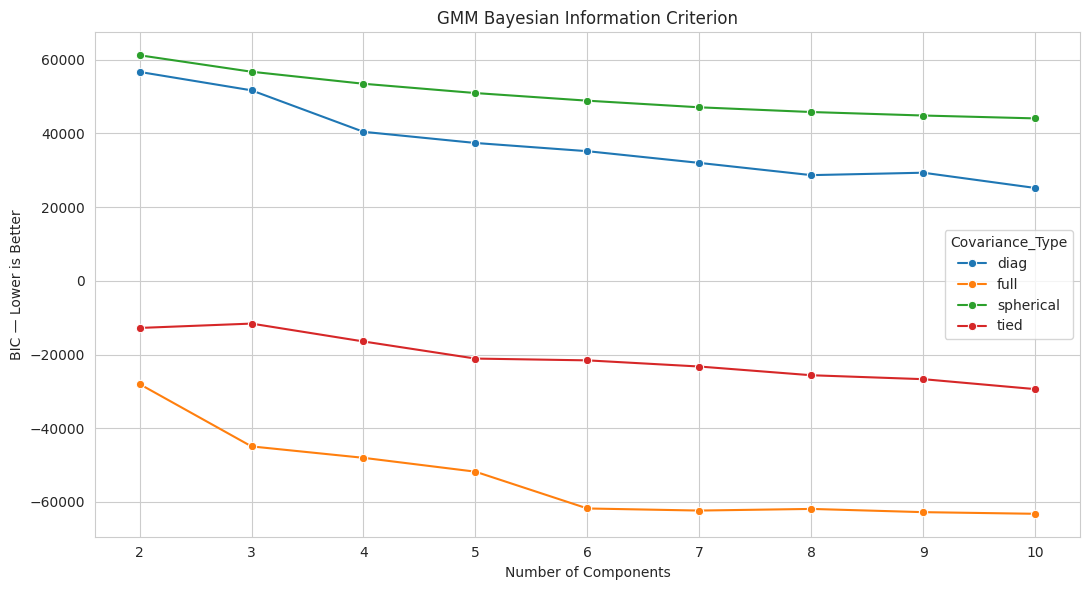

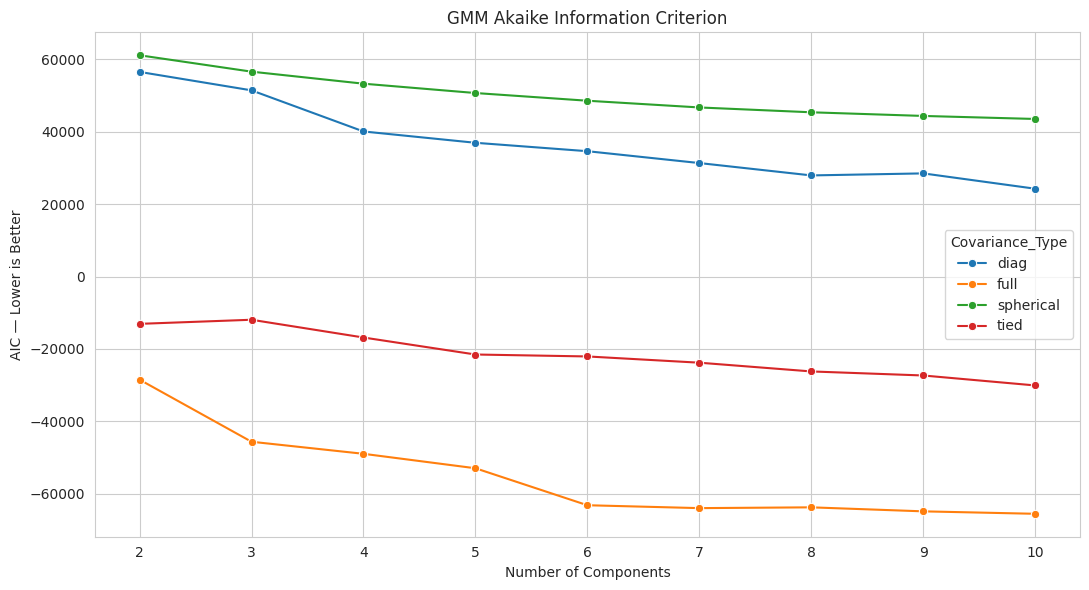

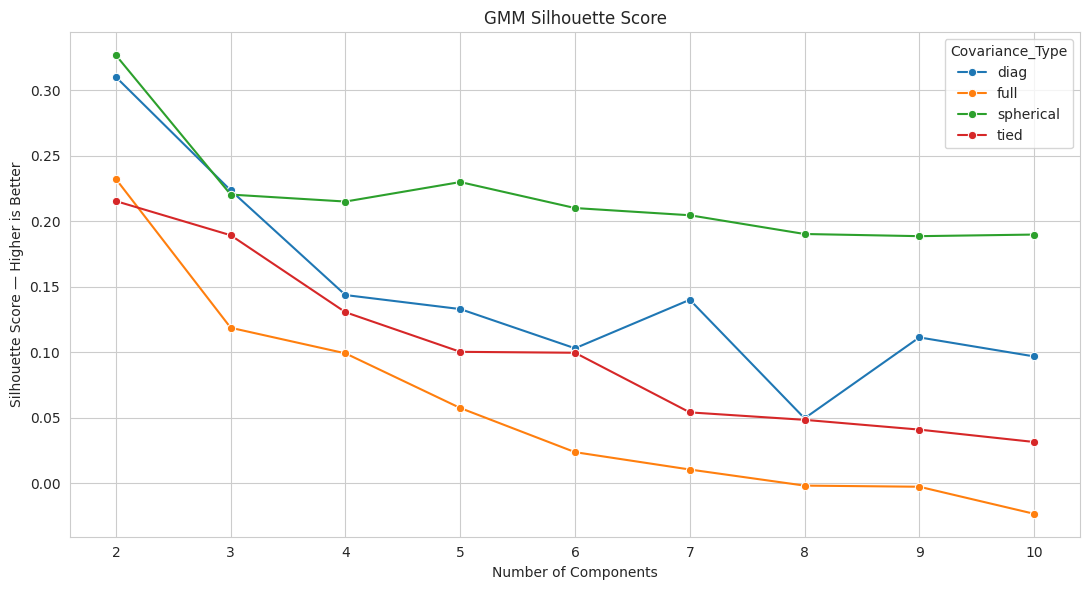

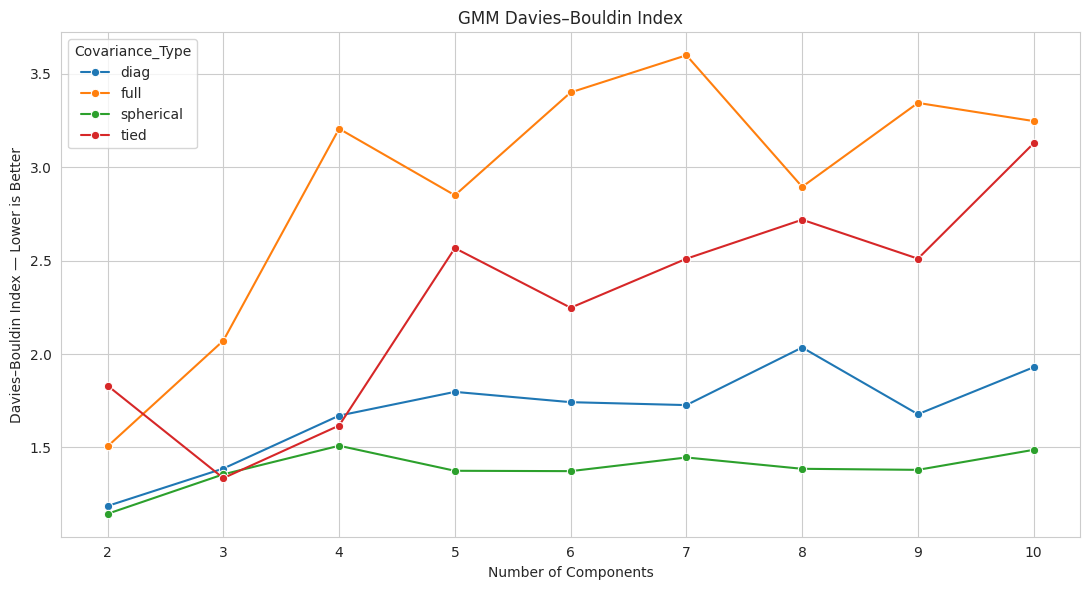

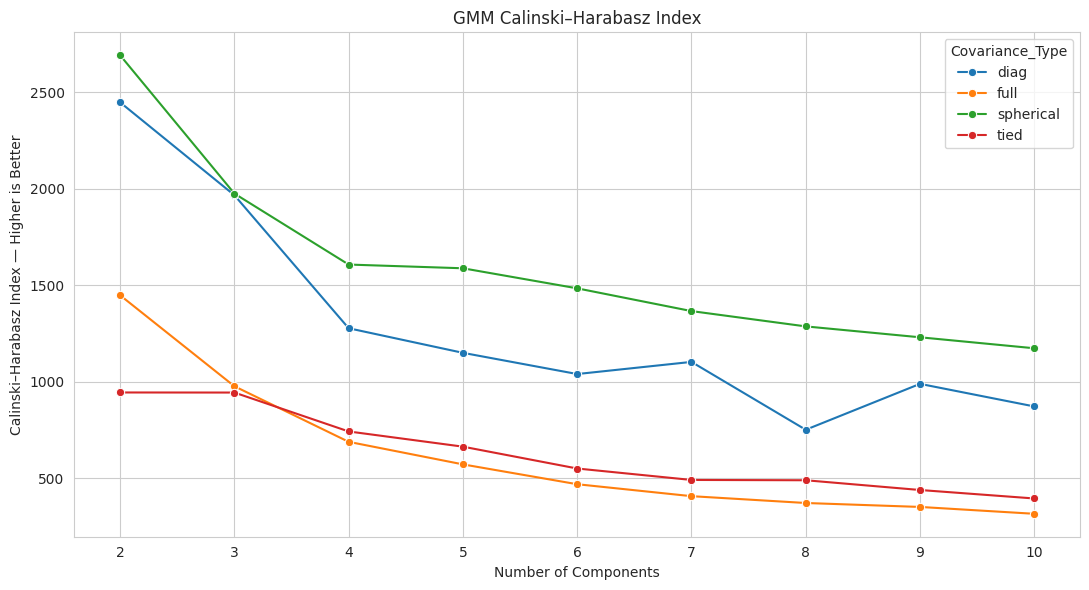

In [ ]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="BIC",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "GMM Bayesian Information Criterion"
)
plt.xlabel("Number of Components")
plt.ylabel("BIC — Lower is Better")
plt.xticks(COMPONENT_VALUES)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "gmm_bic_by_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="AIC",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "GMM Akaike Information Criterion"
)
plt.xlabel("Number of Components")
plt.ylabel("AIC — Lower is Better")
plt.xticks(COMPONENT_VALUES)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "gmm_aic_by_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="Silhouette_Score",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "GMM Silhouette Score"
)
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score — Higher is Better")
plt.xticks(COMPONENT_VALUES)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "gmm_silhouette_by_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="Davies_Bouldin_Index",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "GMM Davies–Bouldin Index"
)
plt.xlabel("Number of Components")
plt.ylabel("Davies–Bouldin Index — Lower is Better")
plt.xticks(COMPONENT_VALUES)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "gmm_davies_bouldin_by_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="Calinski_Harabasz_Index",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "GMM Calinski–Harabasz Index"
)
plt.xlabel("Number of Components")
plt.ylabel(
    "Calinski–Harabasz Index — Higher is Better"
)
plt.xticks(COMPONENT_VALUES)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "gmm_calinski_harabasz_by_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

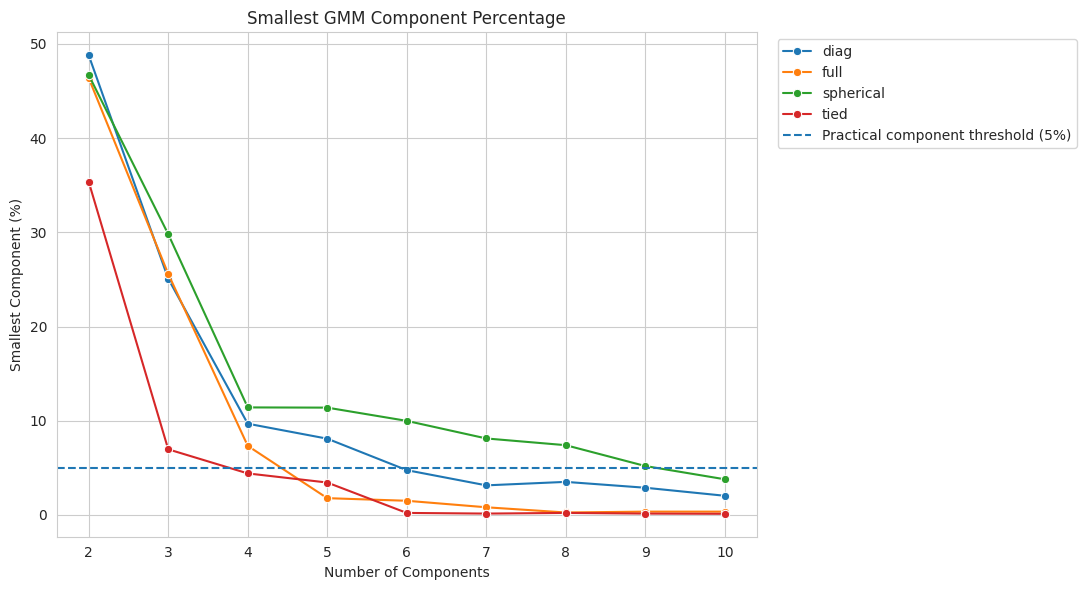

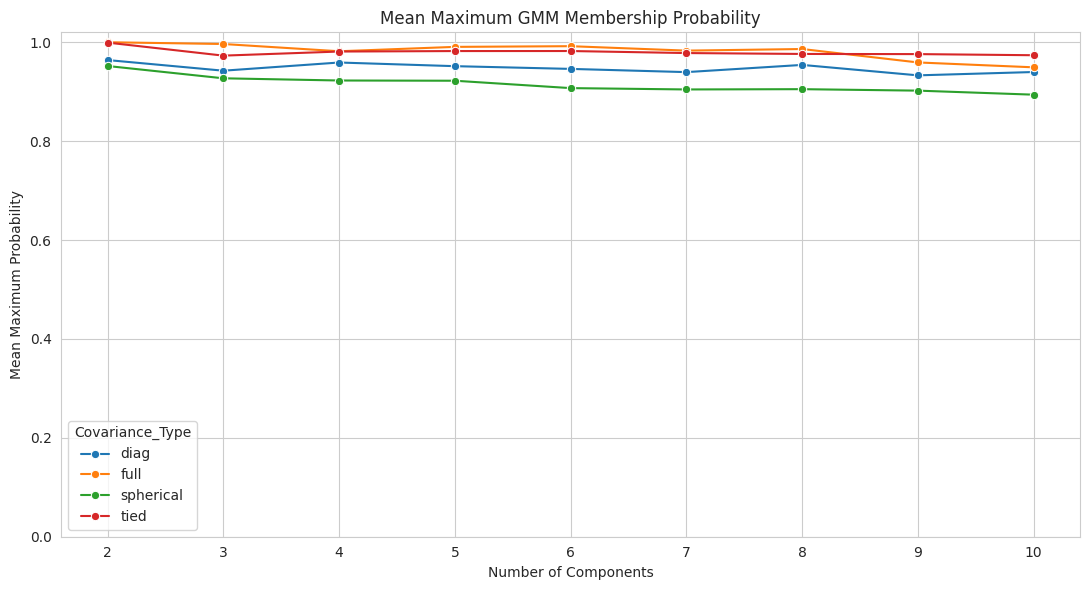

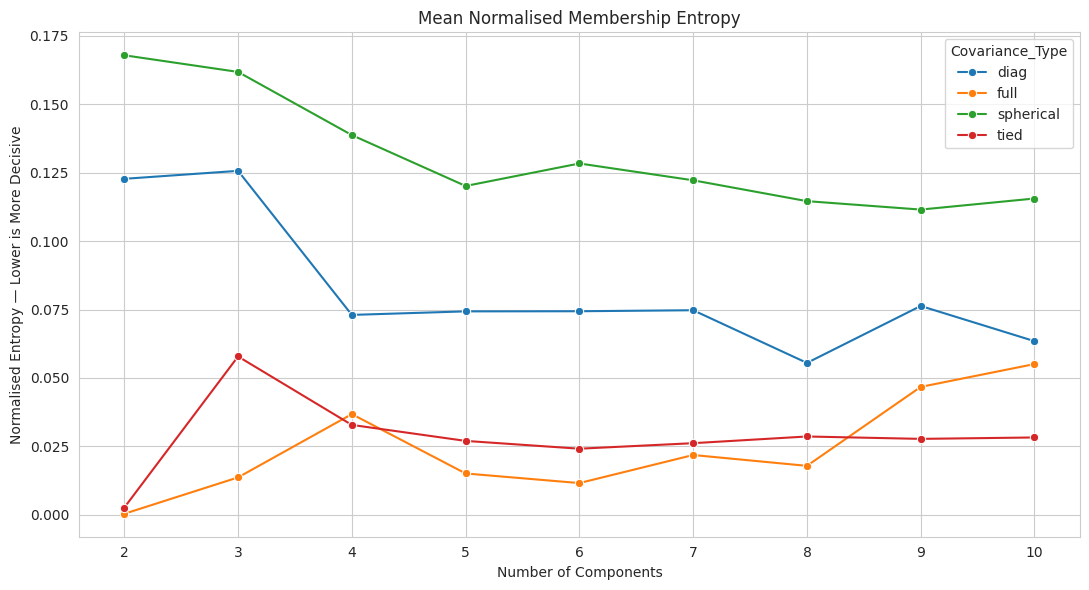

In [ ]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="Smallest_Component_Percentage",
    hue="Covariance_Type",
    marker="o"
)

plt.axhline(
    MINIMUM_COMPONENT_PERCENTAGE,
    linestyle="--",
    label=(
        "Practical component threshold "
        f"({MINIMUM_COMPONENT_PERCENTAGE:.0f}%)"
    )
)

plt.title(
    "Smallest GMM Component Percentage"
)
plt.xlabel("Number of Components")
plt.ylabel("Smallest Component (%)")
plt.xticks(COMPONENT_VALUES)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_smallest_component_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="Mean_Maximum_Probability",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "Mean Maximum GMM Membership Probability"
)
plt.xlabel("Number of Components")
plt.ylabel("Mean Maximum Probability")
plt.xticks(COMPONENT_VALUES)
plt.ylim(0, 1.02)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_mean_maximum_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=grid_results_df,
    x="N_Components",
    y="Mean_Normalised_Entropy",
    hue="Covariance_Type",
    marker="o"
)

plt.title(
    "Mean Normalised Membership Entropy"
)
plt.xlabel("Number of Components")
plt.ylabel(
    "Normalised Entropy — Lower is More Decisive"
)
plt.xticks(COMPONENT_VALUES)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_mean_membership_entropy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Random-seed stability for shortlisted configurations

Each shortlisted configuration is refitted using 20 random states. Hard
component assignments are compared with the baseline assignment using
Adjusted Rand Index.

ARI is invariant to component-number permutations, so component labels do not
need to be manually aligned for this stability calculation.

In [ ]:
seed_stability_runs = []
seed_stability_summary_rows = []

for _, candidate in candidate_grid.iterrows():

    config_name = candidate[
        "Configuration"
    ]

    n_components = int(
        candidate[
            "N_Components"
        ]
    )

    covariance_type = candidate[
        "Covariance_Type"
    ]

    baseline_labels = (
        labels_by_configuration[
            config_name
        ]
    )

    configuration_runs = []

    print("\n" + "=" * 80)
    print(
        "SEED STABILITY:",
        config_name
    )
    print("=" * 80)

    for random_state in range(
        1,
        SEED_STABILITY_RUNS + 1
    ):

        run_start = time.perf_counter()

        try:
            model = build_gmm(
                n_components=n_components,
                covariance_type=covariance_type,
                random_state=random_state,
                n_init=STABILITY_N_INIT
            )

            run_labels = model.fit_predict(X)

            run_ari = adjusted_rand_score(
                baseline_labels,
                run_labels
            )

            run_record = {
                "Configuration": config_name,
                "N_Components": n_components,
                "Covariance_Type": covariance_type,
                "Random_State": random_state,
                "Converged": bool(
                    model.converged_
                ),
                "Iterations": int(
                    model.n_iter_
                ),
                "Adjusted_Rand_Index": float(
                    run_ari
                ),
                "BIC": float(
                    model.bic(X)
                ),
                "Fit_Time_Seconds": (
                    time.perf_counter()
                    - run_start
                ),
                "Error": None
            }

        except Exception as error:

            run_record = {
                "Configuration": config_name,
                "N_Components": n_components,
                "Covariance_Type": covariance_type,
                "Random_State": random_state,
                "Converged": False,
                "Iterations": np.nan,
                "Adjusted_Rand_Index": np.nan,
                "BIC": np.nan,
                "Fit_Time_Seconds": (
                    time.perf_counter()
                    - run_start
                ),
                "Error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )
            }

        seed_stability_runs.append(
            run_record
        )

        configuration_runs.append(
            run_record
        )

    configuration_runs_df = (
        pd.DataFrame(
            configuration_runs
        )
    )

    successful_runs = (
        configuration_runs_df[
            configuration_runs_df[
                "Adjusted_Rand_Index"
            ].notna()
        ]
    )

    seed_stability_summary_rows.append({
        "Configuration": config_name,
        "N_Components": n_components,
        "Covariance_Type": covariance_type,
        "Requested_Runs": (
            SEED_STABILITY_RUNS
        ),
        "Successful_Runs": int(
            len(successful_runs)
        ),
        "Convergence_Rate": float(
            configuration_runs_df[
                "Converged"
            ].mean()
        ),
        "Mean_Seed_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].mean()
        ),
        "Median_Seed_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].median()
        ),
        "Minimum_Seed_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].min()
        ),
        "Maximum_Seed_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].max()
        ),
        "Seed_ARI_Standard_Deviation": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].std()
        ),
        "Mean_BIC_Across_Seeds": float(
            successful_runs[
                "BIC"
            ].mean()
        )
    })

seed_stability_runs_df = pd.DataFrame(
    seed_stability_runs
)

seed_stability_summary_df = (
    pd.DataFrame(
        seed_stability_summary_rows
    )
    .round(6)
)

display(seed_stability_summary_df)

seed_stability_runs_df.to_csv(
    STABILITY_DIR / "gmm_seed_stability_runs.csv",
    index=False
)

seed_stability_summary_df.to_csv(
    STABILITY_DIR / "gmm_seed_stability_summary.csv",
    index=False
)


SEED STABILITY: GMM_C4_full

SEED STABILITY: GMM_C2_tied

SEED STABILITY: GMM_C5_diag

SEED STABILITY: GMM_C9_spherical

SEED STABILITY: GMM_C2_spherical


,Configuration,N_Components,Covariance_Type,Requested_Runs,Successful_Runs,Convergence_Rate,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_BIC_Across_Seeds
0,GMM_C4_full,4,full,20,20,1.0000,0.6367,0.4205,0.4204,1.0000,0.2736,"-41,443.4915"
1,GMM_C2_tied,2,tied,20,20,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,"-12,785.5908"
2,GMM_C5_diag,5,diag,20,20,1.0000,0.8095,0.7924,0.6129,1.0000,0.1521,"37,642.5801"
3,GMM_C9_spherical,9,spherical,20,20,1.0000,0.9632,0.9806,0.7011,0.9952,0.0647,"44,883.0407"
4,GMM_C2_spherical,2,spherical,20,20,1.0000,0.9998,1.0000,0.9991,1.0000,0.0004,"61,230.0271"


## 14. Repeated 80% subsampling stability for shortlisted configurations

For each configuration:

1. draw 80% of customers without replacement;
2. fit the same GMM configuration to the subsample;
3. compare the subsample assignments with the baseline full-data assignments
   restricted to the same customers;
4. calculate ARI.

This tests whether the discovered structure remains similar when the customer
sample changes.

In [ ]:
subsampling_runs = []
subsampling_summary_rows = []

sample_size = int(
    len(X) * SUBSAMPLE_FRACTION
)

for _, candidate in candidate_grid.iterrows():

    config_name = candidate[
        "Configuration"
    ]

    n_components = int(
        candidate[
            "N_Components"
        ]
    )

    covariance_type = candidate[
        "Covariance_Type"
    ]

    baseline_labels = (
        labels_by_configuration[
            config_name
        ]
    )

    random_generator = np.random.default_rng(
        STABILITY_RANDOM_STATE
        + n_components * 100
        + COVARIANCE_TYPES.index(
            covariance_type
        )
    )

    configuration_runs = []

    print("\n" + "=" * 80)
    print(
        "SUBSAMPLING STABILITY:",
        config_name
    )
    print("=" * 80)

    for run_number in range(
        1,
        SUBSAMPLE_STABILITY_RUNS + 1
    ):

        sampled_positions = (
            random_generator.choice(
                len(X),
                size=sample_size,
                replace=False
            )
        )

        sampled_positions = np.sort(
            sampled_positions
        )

        X_sample = X.iloc[
            sampled_positions
        ]

        baseline_sample_labels = (
            baseline_labels[
                sampled_positions
            ]
        )

        run_start = time.perf_counter()

        try:
            model = build_gmm(
                n_components=n_components,
                covariance_type=covariance_type,
                random_state=(
                    STABILITY_RANDOM_STATE
                    + n_components * 1000
                    + run_number
                ),
                n_init=STABILITY_N_INIT
            )

            sample_labels = (
                model.fit_predict(
                    X_sample
                )
            )

            run_ari = adjusted_rand_score(
                baseline_sample_labels,
                sample_labels
            )

            run_record = {
                "Configuration": config_name,
                "N_Components": n_components,
                "Covariance_Type": covariance_type,
                "Run": run_number,
                "Sample_Size": sample_size,
                "Sample_Fraction": (
                    SUBSAMPLE_FRACTION
                ),
                "Converged": bool(
                    model.converged_
                ),
                "Iterations": int(
                    model.n_iter_
                ),
                "Adjusted_Rand_Index": float(
                    run_ari
                ),
                "Fit_Time_Seconds": (
                    time.perf_counter()
                    - run_start
                ),
                "Error": None
            }

        except Exception as error:

            run_record = {
                "Configuration": config_name,
                "N_Components": n_components,
                "Covariance_Type": covariance_type,
                "Run": run_number,
                "Sample_Size": sample_size,
                "Sample_Fraction": (
                    SUBSAMPLE_FRACTION
                ),
                "Converged": False,
                "Iterations": np.nan,
                "Adjusted_Rand_Index": np.nan,
                "Fit_Time_Seconds": (
                    time.perf_counter()
                    - run_start
                ),
                "Error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )
            }

        subsampling_runs.append(
            run_record
        )

        configuration_runs.append(
            run_record
        )

    configuration_runs_df = pd.DataFrame(
        configuration_runs
    )

    successful_runs = (
        configuration_runs_df[
            configuration_runs_df[
                "Adjusted_Rand_Index"
            ].notna()
        ]
    )

    subsampling_summary_rows.append({
        "Configuration": config_name,
        "N_Components": n_components,
        "Covariance_Type": covariance_type,
        "Requested_Runs": (
            SUBSAMPLE_STABILITY_RUNS
        ),
        "Successful_Runs": int(
            len(successful_runs)
        ),
        "Sample_Size": sample_size,
        "Sample_Fraction": (
            SUBSAMPLE_FRACTION
        ),
        "Convergence_Rate": float(
            configuration_runs_df[
                "Converged"
            ].mean()
        ),
        "Mean_Subsampling_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].mean()
        ),
        "Median_Subsampling_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].median()
        ),
        "Minimum_Subsampling_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].min()
        ),
        "Maximum_Subsampling_ARI": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].max()
        ),
        "Subsampling_ARI_Standard_Deviation": float(
            successful_runs[
                "Adjusted_Rand_Index"
            ].std()
        )
    })

subsampling_runs_df = pd.DataFrame(
    subsampling_runs
)

subsampling_summary_df = (
    pd.DataFrame(
        subsampling_summary_rows
    )
    .round(6)
)

display(subsampling_summary_df)

subsampling_runs_df.to_csv(
    STABILITY_DIR
    / "gmm_subsampling_stability_runs.csv",
    index=False
)

subsampling_summary_df.to_csv(
    STABILITY_DIR
    / "gmm_subsampling_stability_summary.csv",
    index=False
)


SUBSAMPLING STABILITY: GMM_C4_full

SUBSAMPLING STABILITY: GMM_C2_tied

SUBSAMPLING STABILITY: GMM_C5_diag

SUBSAMPLING STABILITY: GMM_C9_spherical

SUBSAMPLING STABILITY: GMM_C2_spherical


,Configuration,N_Components,Covariance_Type,Requested_Runs,Successful_Runs,Sample_Size,Sample_Fraction,Convergence_Rate,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation
0,GMM_C4_full,4,full,30,30,3470,0.8000,1.0000,0.7110,0.7780,0.3960,0.9935,0.2386
1,GMM_C2_tied,2,tied,30,30,3470,0.8000,1.0000,0.9963,0.9965,0.9919,1.0000,0.0026
2,GMM_C5_diag,5,diag,30,30,3470,0.8000,1.0000,0.7692,0.7595,0.6031,0.9881,0.1216
3,GMM_C9_spherical,9,spherical,30,30,3470,0.8000,1.0000,0.8895,0.9120,0.5598,0.9549,0.0909
4,GMM_C2_spherical,2,spherical,30,30,3470,0.8000,1.0000,0.9891,0.9919,0.9567,0.9988,0.0091


## 15. Combine candidate technical, stability and feasibility evidence

In [ ]:
candidate_evidence = (
    candidate_grid
    .merge(
        seed_stability_summary_df,
        on=[
            "Configuration",
            "N_Components",
            "Covariance_Type"
        ],
        how="left",
        validate="one_to_one"
    )
    .merge(
        subsampling_summary_df,
        on=[
            "Configuration",
            "N_Components",
            "Covariance_Type"
        ],
        how="left",
        validate="one_to_one",
        suffixes=(
            "_Seed",
            "_Subsample"
        )
    )
    .round(6)
)

candidate_evidence.to_csv(
    CANDIDATE_DIR
    / "gmm_candidate_complete_evidence.csv",
    index=False
)

display(candidate_evidence)

,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Largest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,Empty_Component_Count,All_Components_At_Least_5_Percent,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Maximum_Normalised_Entropy,Minimum_Covariance_Value,AIC_Rank,BIC_Rank,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Common_Validation_Rank,Requested_Runs_Seed,Successful_Runs_Seed,Convergence_Rate_Seed,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_BIC_Across_Seeds,Requested_Runs_Subsample,Successful_Runs_Subsample,Sample_Size,Sample_Fraction,Convergence_Rate_Subsample,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation
0,GMM_C4_full,4,full,True,20,0.6644,5.6751,5.6749,"-48,951.2385","-48,039.5893",0.0991,3.2064,688.2534,318,1493,7.3306,34.4168,0,True,0.9817,1.0000,39,0.8990,0.9636,1.0000,39,0.8990,0.0368,0.5038,0.0000,7.0000,7.0000,24.0000,32.0000,24.0000,26.6667,20,20,1.0000,0.6367,0.4205,0.4204,1.0000,0.2736,"-41,443.4915",30,30,3470,0.8000,1.0000,0.7110,0.7780,0.3960,0.9935,0.2386
1,GMM_C2_tied,2,tied,True,10,0.3035,1.5152,1.5147,"-13,059.7105","-12,785.5783",0.2153,1.8308,944.0028,1534,2804,35.3619,64.6381,0,True,0.9992,1.0000,1,0.0231,0.9984,1.0000,1,0.0231,0.0027,0.9990,0.0000,17.0000,17.0000,7.0000,20.0000,19.0000,15.3333,20,20,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,"-12,785.5908",30,30,3470,0.8000,1.0000,0.9963,0.9965,0.9919,1.0000,0.0026
2,GMM_C5_diag,5,diag,True,20,0.4916,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1.7975,"1,149.3977",351,1352,8.0913,31.1664,0,True,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.6217,0.0000,24.0000,24.0000,17.0000,19.0000,14.0000,16.6667,20,20,1.0000,0.8095,0.7924,0.6129,1.0000,0.1521,"37,642.5801",30,30,3470,0.8000,1.0000,0.7692,0.7595,0.6031,0.9881,0.1216
3,GMM_C9_spherical,9,spherical,True,20,0.4637,-5.0948,-5.0952,"44,362.8425","44,872.8560",0.1886,1.3799,"1,229.9250",225,787,5.1867,18.1420,0,True,0.9021,0.9820,305,7.0309,0.8163,0.9661,251,5.7861,0.1115,0.6017,0.0768,27.0000,27.0000,14.0000,7.0000,12.0000,11.0000,20,20,1.0000,0.9632,0.9806,0.7011,0.9952,0.0647,"44,883.0407",30,30,3470,0.8000,1.0000,0.8895,0.9120,0.5598,0.9549,0.0909
4,GMM_C2_spherical,2,spherical,True,2,0.0686,-7.0410,-7.0410,"61,121.6505","61,230.0284",0.3267,1.1447,"2,691.2465",2026,2312,46.7035,53.2965,0,True,0.9519,0.9991,109,2.5127,0.9038,0.9982,109,2.5127,0.1679,1.0000,0.3521,36.0000,36.0000,1.0000,1.0000,1.0000,1.0000,20,20,1.0000,0.9998,1.0000,0.9991,1.0000,0.0004,"61,230.0271",30,30,3470,0.8000,1.0000,0.9891,0.9919,0.9567,0.9988,0.0091


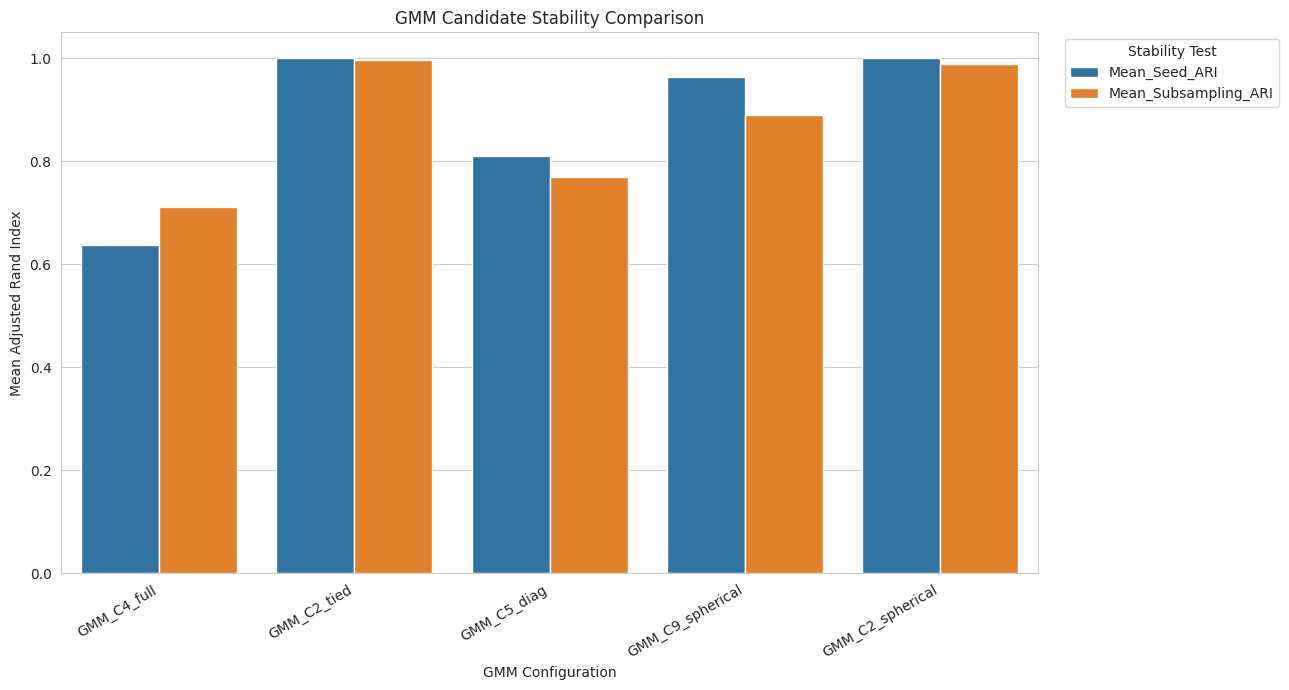

In [ ]:
stability_plot_data = (
    candidate_evidence[
        [
            "Configuration",
            "Mean_Seed_ARI",
            "Mean_Subsampling_ARI"
        ]
    ]
    .melt(
        id_vars="Configuration",
        var_name="Stability_Test",
        value_name="Mean_ARI"
    )
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=stability_plot_data,
    x="Configuration",
    y="Mean_ARI",
    hue="Stability_Test"
)

plt.title(
    "GMM Candidate Stability Comparison"
)
plt.xlabel("GMM Configuration")
plt.ylabel("Mean Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.xticks(
    rotation=30,
    ha="right"
)
plt.legend(
    title="Stability Test",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_candidate_stability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 16. Visualise shortlisted configurations in the common PCA space



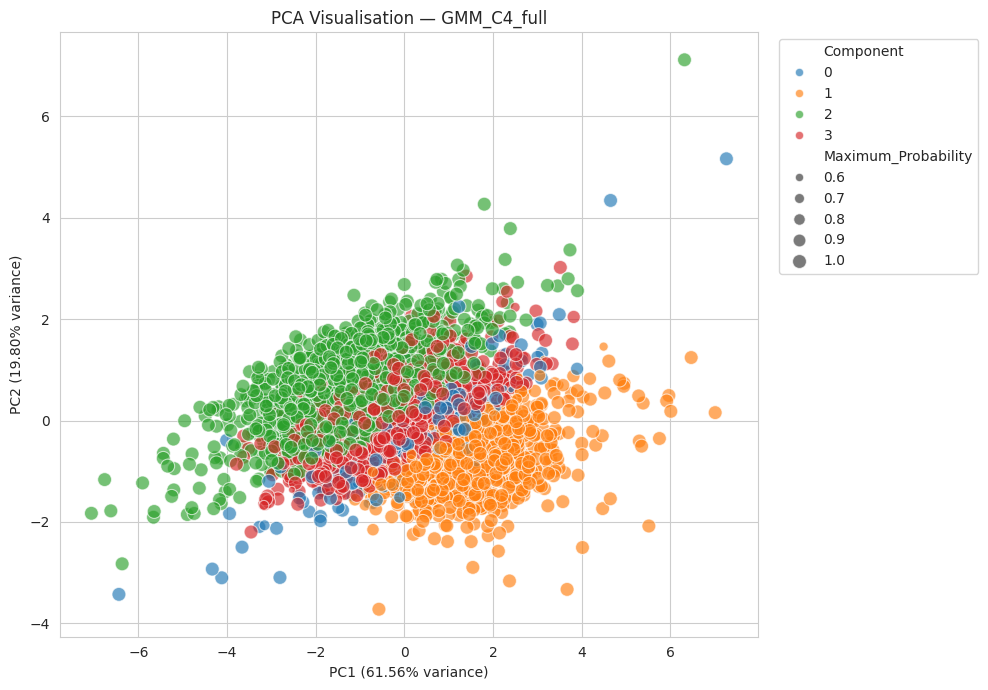

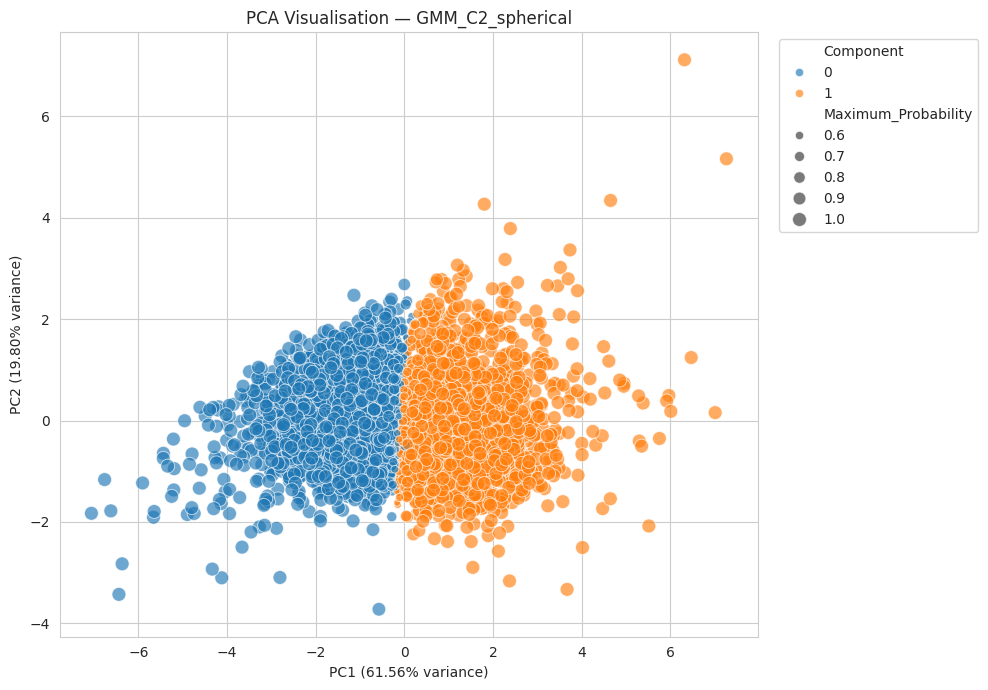

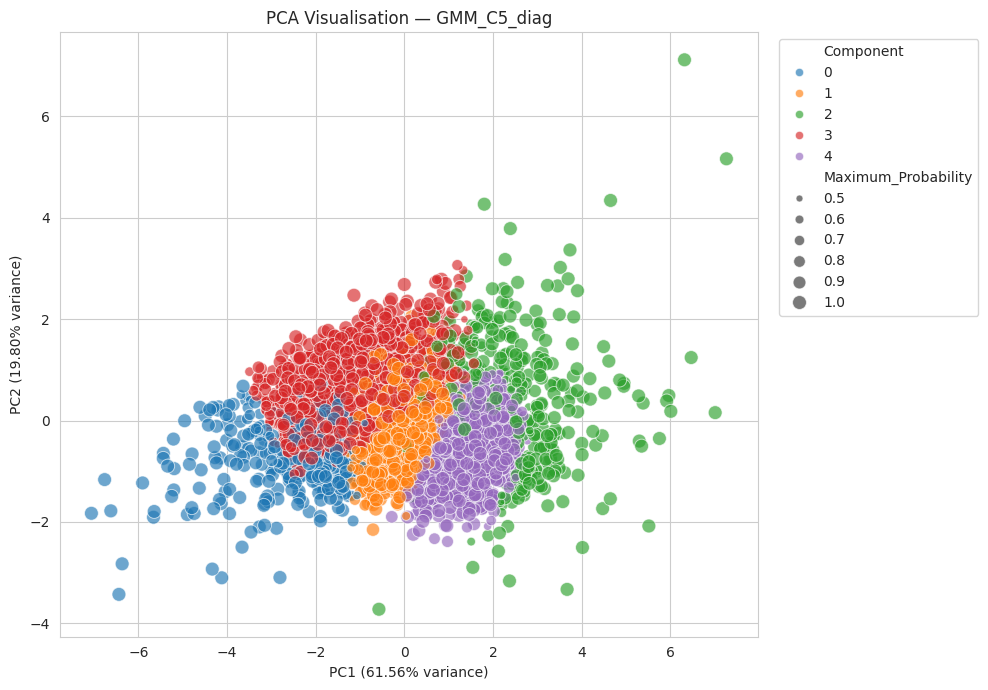

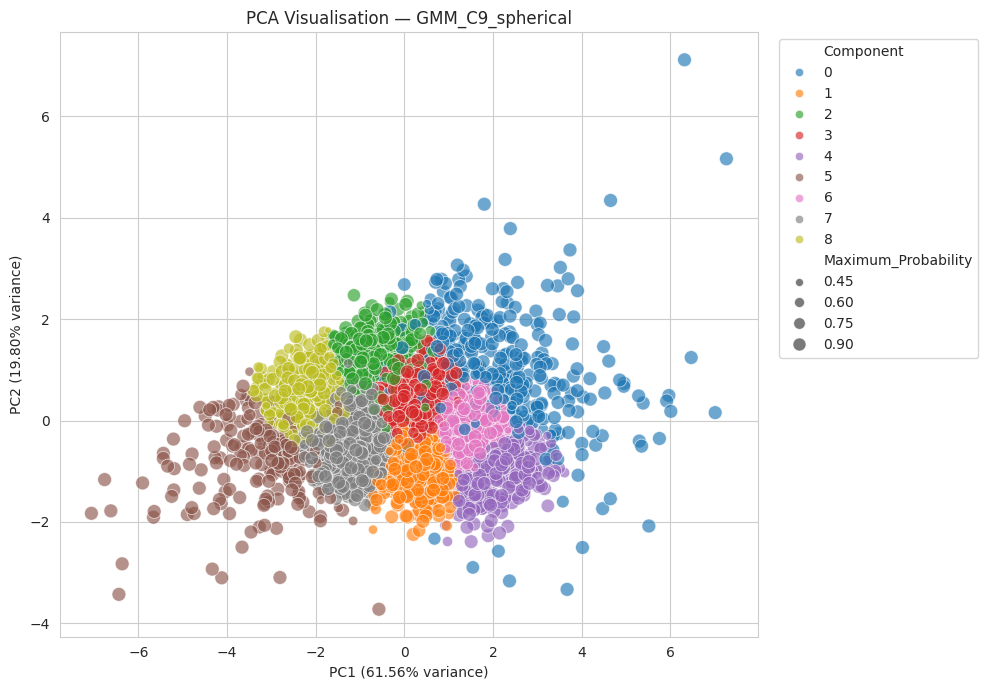

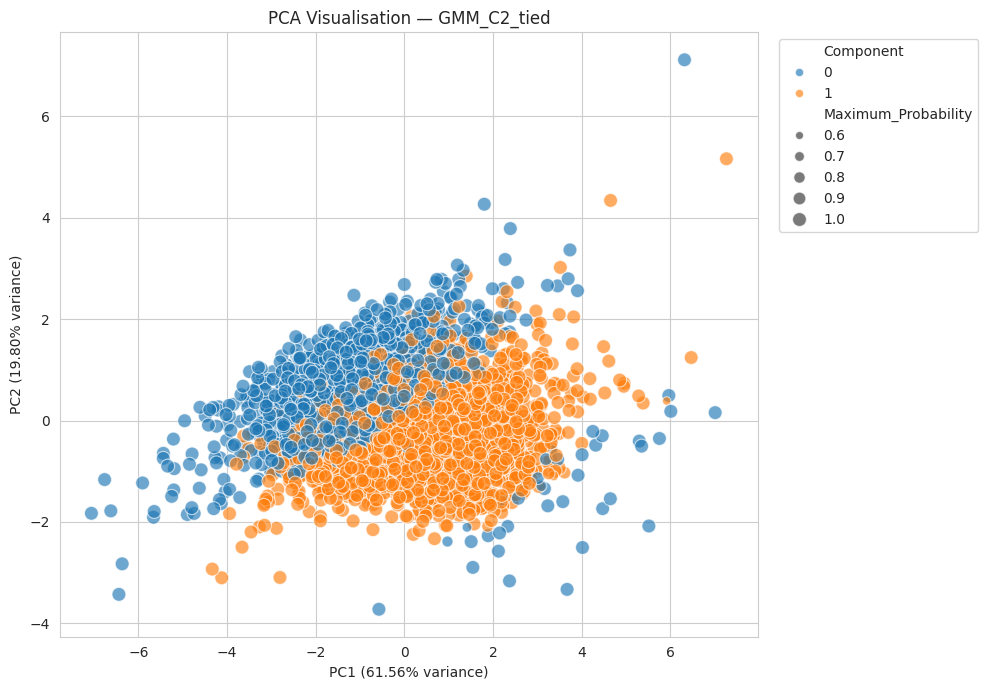

,Configuration,Component,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,GMM_C4_full,0,103.4434,5.1761,"2,639.2519",714.1591,376.4571,52.8899,"1,483.3113"
1,GMM_C4_full,1,18.9818,10.1371,"5,235.9311",422.4372,246.2409,128.7002,"2,993.7696"
2,GMM_C4_full,2,156.6825,1.0000,411.2455,411.2455,270.2907,21.6772,270.2907
3,GMM_C4_full,3,84.8131,2.3685,830.7178,348.8477,208.0005,46.9248,494.9164
4,GMM_C2_spherical,0,142.7591,1.7419,330.8381,212.9000,115.7727,21.6634,172.9176
5,GMM_C2_spherical,1,48.5264,6.4892,"3,554.0359",597.0639,372.2441,96.4109,"2,076.8473"
6,GMM_C5_diag,0,134.9008,2.1123,242.5773,116.8574,44.8485,12.7807,97.9791
7,GMM_C5_diag,1,74.3122,3.0256,777.2226,275.1904,158.2757,48.2354,438.0272
8,GMM_C5_diag,2,63.1368,14.0997,"13,365.0921","1,659.3091","1,052.3822",149.9259,"7,697.7778"
9,GMM_C5_diag,3,156.2049,1.0000,326.9049,326.9049,197.7108,21.9645,197.7108


In [ ]:
candidate_profile_tables = []

for config_name in candidate_configuration_names:

    candidate_row = candidate_grid[
        candidate_grid[
            "Configuration"
        ] == config_name
    ].iloc[0]

    labels = labels_by_configuration[
        config_name
    ]

    probabilities = (
        probabilities_by_configuration[
            config_name
        ]
    )

    maximum_probability = probabilities.max(
        axis=1
    )

    plot_data = pca_data.copy()

    plot_data["Component"] = labels

    plot_data[
        "Maximum_Probability"
    ] = maximum_probability

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=plot_data,
        x="PC1",
        y="PC2",
        hue="Component",
        size="Maximum_Probability",
        sizes=(20, 100),
        palette="tab10",
        alpha=0.65
    )

    plt.title(
        f"PCA Visualisation — {config_name}"
    )
    plt.xlabel(
        "PC1 "
        f"({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
    )
    plt.ylabel(
        "PC2 "
        f"({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
    )
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"{config_name}_pca_components.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    profile = (
        mean_profiles_by_configuration[
            config_name
        ]
        .reset_index()
    )

    profile.insert(
        0,
        "Configuration",
        config_name
    )

    candidate_profile_tables.append(
        profile
    )

candidate_mean_profiles = pd.concat(
    candidate_profile_tables,
    ignore_index=True
)

candidate_mean_profiles.to_csv(
    CANDIDATE_DIR
    / "gmm_candidate_mean_profiles.csv",
    index=False
)

display(candidate_mean_profiles)

## 17. Create candidate original-scale profile heatmaps

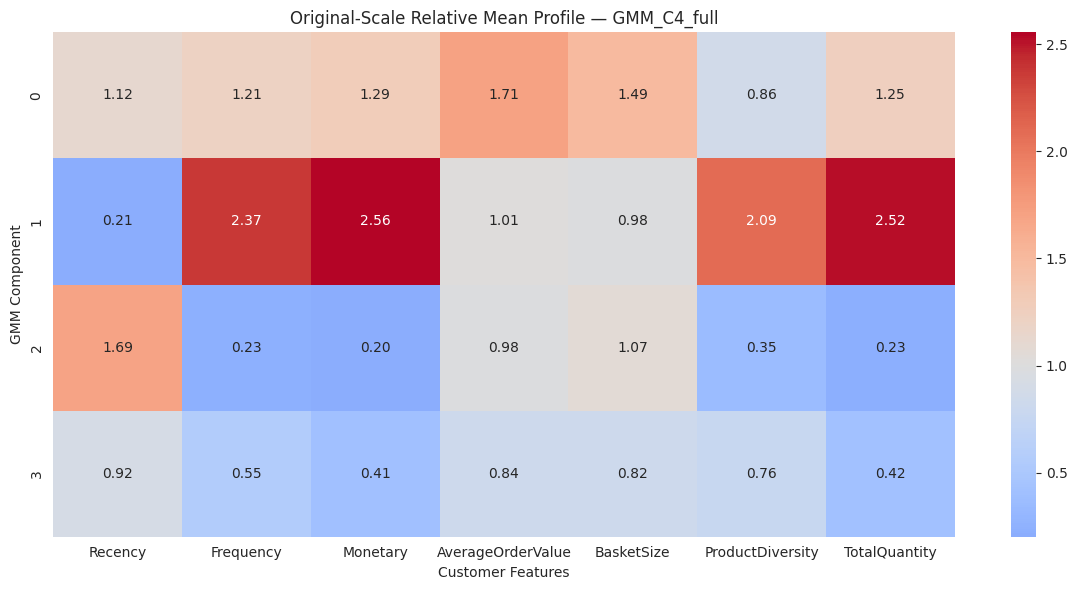

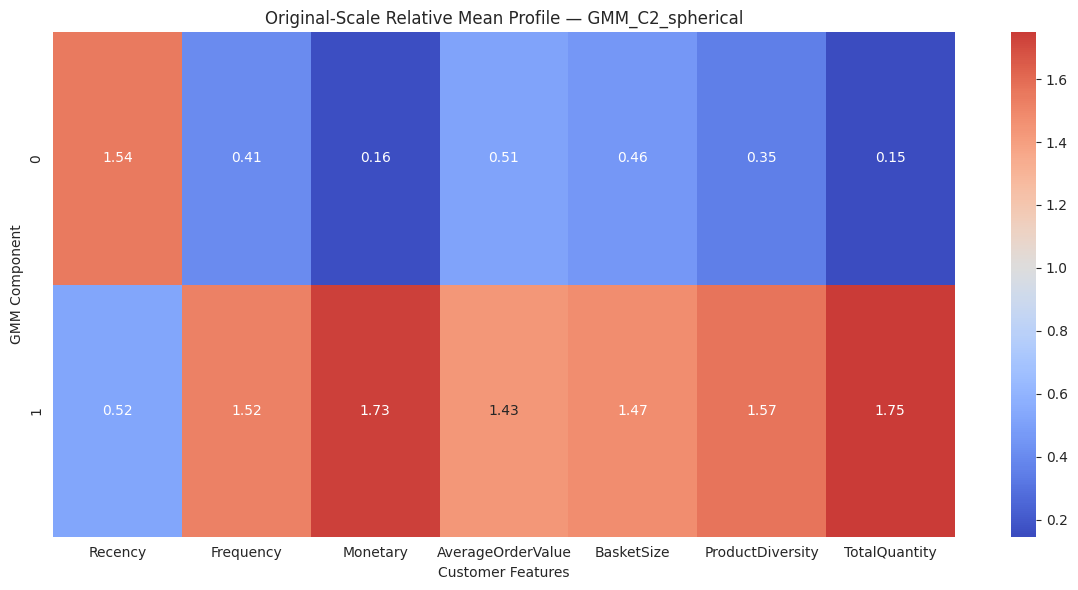

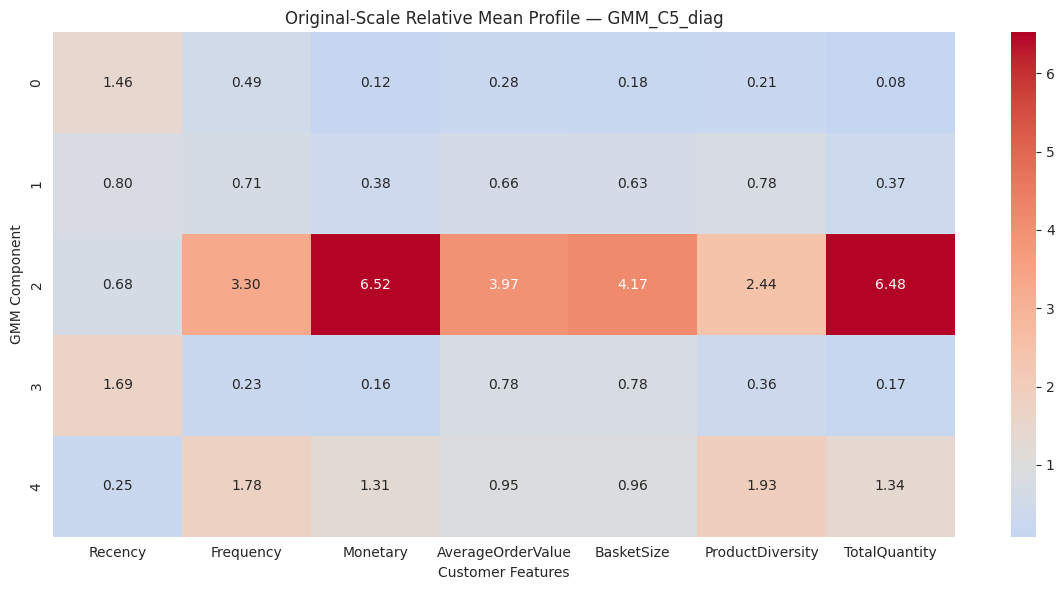

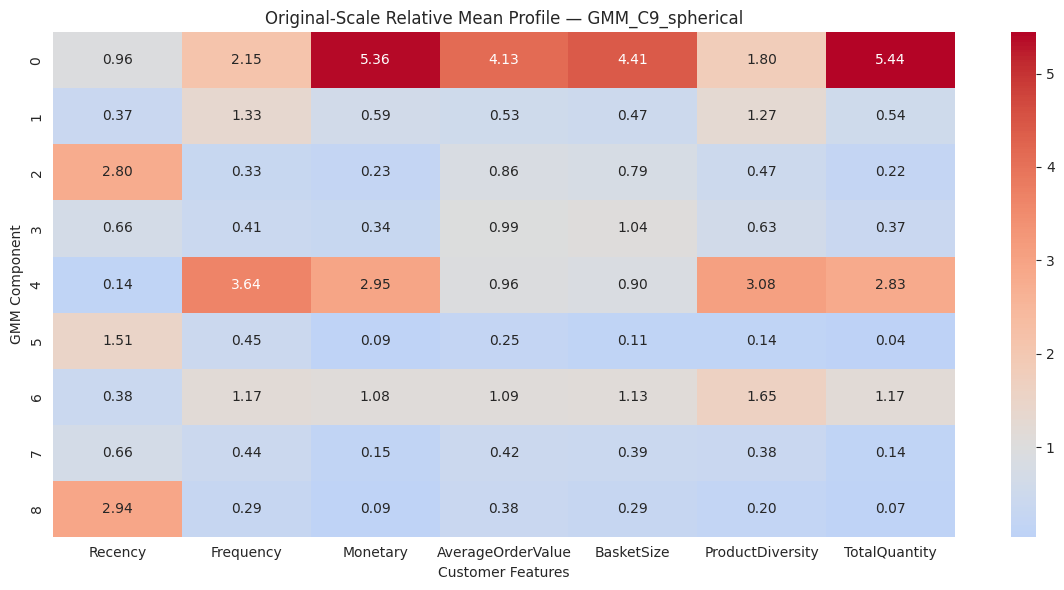

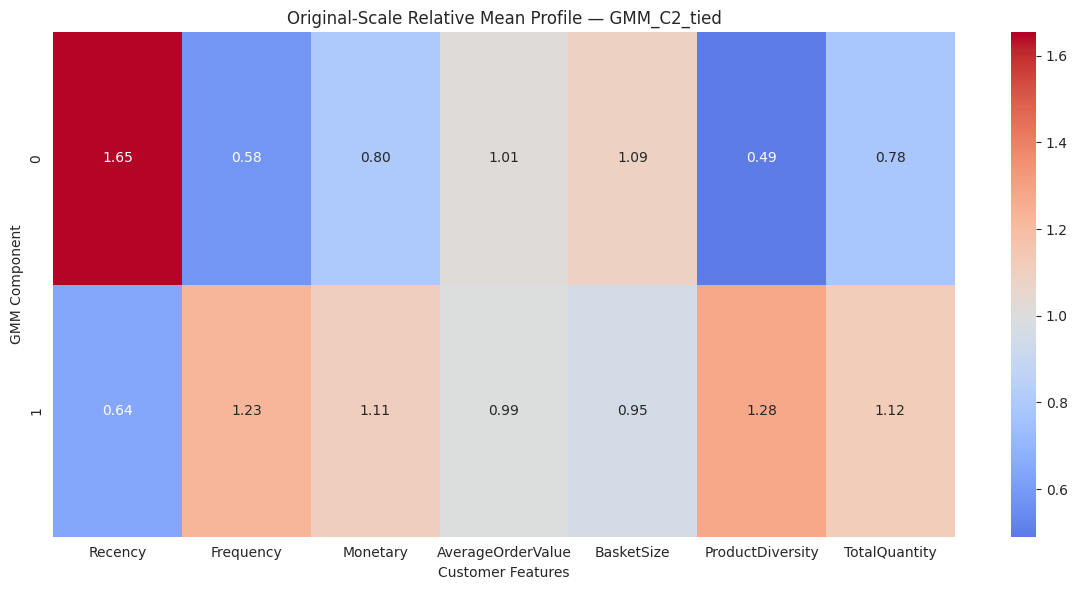

In [ ]:
overall_original_means = (
    original_scale_data[
        FEATURE_COLUMNS
    ]
    .mean()
)

for config_name in candidate_configuration_names:

    mean_profile = (
        mean_profiles_by_configuration[
            config_name
        ]
    )

    relative_profile = (
        mean_profile
        / overall_original_means
    )

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        relative_profile,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=1
    )

    plt.title(
        f"Original-Scale Relative Mean Profile — {config_name}"
    )
    plt.xlabel("Customer Features")
    plt.ylabel("GMM Component")
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"{config_name}_relative_profile_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 18. Review all five-component covariance structures

The final GMM comparison will use five components so that it can be compared
directly with the frozen K-Means K=5 model.

This table does not select the final GMM yet. It identifies the strongest
five-component covariance structure to carry forward after the statistical
configuration is reviewed.

,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Largest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,Empty_Component_Count,All_Components_At_Least_5_Percent,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Maximum_Normalised_Entropy,Minimum_Covariance_Value,AIC_Rank,BIC_Rank,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Common_Validation_Rank
0,GMM_C5_full,5,full,True,44,1.1108,6.1436,6.1434,"-52,943.6436","-51,802.4884",0.0574,2.8501,571.4015,77,1486,1.7750,34.2554,0,False,0.9906,1.0000,18,0.4149,0.9813,1.0000,18,0.4149,0.0151,0.6586,0.0000,6.0000,6.0000,26.0000,29.0000,26.0000,27.0000
1,GMM_C5_tied,5,tied,True,16,1.0833,2.4966,2.4963,"-21,526.5087","-21,099.3724",0.1003,2.5671,663.2274,149,1851,3.4348,42.6694,0,False,0.9821,1.0000,46,1.0604,0.9643,1.0000,46,1.0604,0.0270,0.4307,0.0000,15.0000,15.0000,22.0000,27.0000,25.0000,24.6667
2,GMM_C5_diag,5,diag,True,20,0.4916,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1.7975,"1,149.3977",351,1352,8.0913,31.1664,0,True,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.6217,0.0000,24.0000,24.0000,17.0000,19.0000,14.0000,16.6667
3,GMM_C5_spherical,5,spherical,True,11,0.2916,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,1.3749,"1,587.4952",494,1608,11.3877,37.0678,0,True,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.7705,0.1421,31.0000,31.0000,4.0000,6.0000,6.0000,5.3333


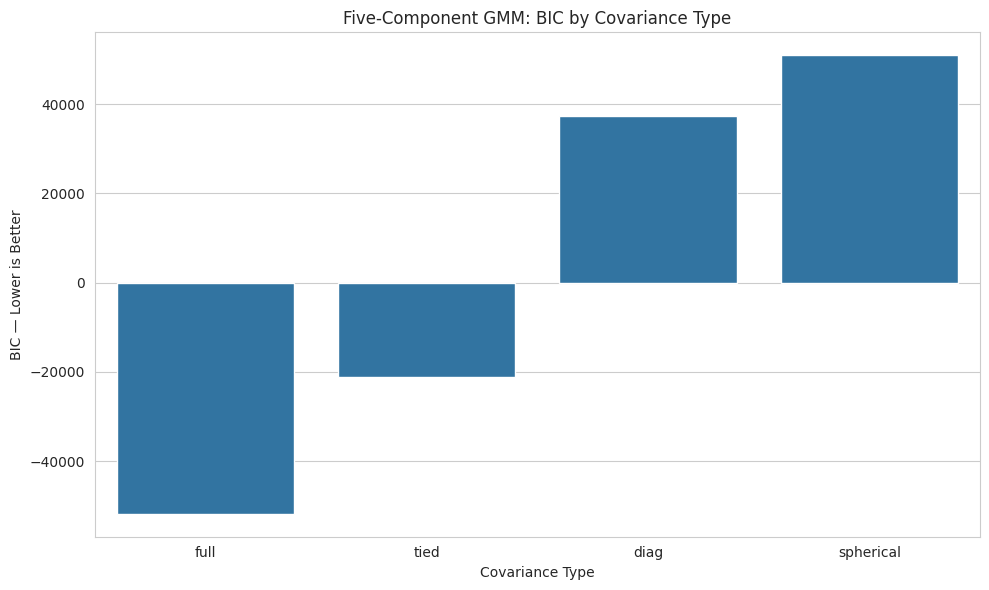

In [ ]:
five_component_review = (
    grid_results_df[
        grid_results_df[
            "N_Components"
        ] == 5
    ]
    .copy()
    .sort_values(
        [
            "BIC",
            "AIC"
        ]
    )
    .reset_index(drop=True)
)

display(five_component_review)

five_component_review.to_csv(
    TABLES_DIR
    / "gmm_five_component_covariance_review.csv",
    index=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=five_component_review,
    x="Covariance_Type",
    y="BIC"
)

plt.title(
    "Five-Component GMM: BIC by Covariance Type"
)
plt.xlabel("Covariance Type")
plt.ylabel("BIC — Lower is Better")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_five_component_bic_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 19. Create a decision-support summary for Step 4

The next step will select the statistical GMM configuration after reviewing:

- AIC and BIC;
- common internal validation;
- convergence;
- component-size feasibility;
- seed stability;
- subsampling stability;
- customer membership decisiveness;
- original-scale profile interpretability.

No single metric is treated as an automatic winner.

In [ ]:
best_bic_row = feasible_grid.loc[
    feasible_grid[
        "BIC"
    ].idxmin()
]

best_aic_row = feasible_grid.loc[
    feasible_grid[
        "AIC"
    ].idxmin()
]

best_silhouette_row = feasible_grid.loc[
    feasible_grid[
        "Silhouette_Score"
    ].idxmax()
]

best_five_bic_row = (
    five_component_review
    .iloc[0]
)

decision_support_summary = pd.DataFrame({
    "Decision_Role": [
        "Lowest feasible BIC",
        "Lowest feasible AIC",
        "Highest feasible Silhouette",
        "Lowest-BIC five-component configuration"
    ],
    "Configuration": [
        best_bic_row[
            "Configuration"
        ],
        best_aic_row[
            "Configuration"
        ],
        best_silhouette_row[
            "Configuration"
        ],
        best_five_bic_row[
            "Configuration"
        ]
    ],
    "N_Components": [
        best_bic_row[
            "N_Components"
        ],
        best_aic_row[
            "N_Components"
        ],
        best_silhouette_row[
            "N_Components"
        ],
        best_five_bic_row[
            "N_Components"
        ]
    ],
    "Covariance_Type": [
        best_bic_row[
            "Covariance_Type"
        ],
        best_aic_row[
            "Covariance_Type"
        ],
        best_silhouette_row[
            "Covariance_Type"
        ],
        best_five_bic_row[
            "Covariance_Type"
        ]
    ],
    "Interpretation": [
        (
            "Primary likelihood-based statistical "
            "candidate with stronger complexity penalty."
        ),
        (
            "Alternative likelihood-based candidate "
            "with a lighter complexity penalty."
        ),
        (
            "Strongest common geometric separation "
            "among feasible GMM configurations."
        ),
        (
            "Direct five-component candidate for the "
            "later K-Means K=5 comparison."
        )
    ]
})

display(decision_support_summary)

decision_support_summary.to_csv(
    TABLES_DIR
    / "gmm_step4_decision_support_summary.csv",
    index=False
)

,Decision_Role,Configuration,N_Components,Covariance_Type,Interpretation
0,Lowest feasible BIC,GMM_C4_full,4,full,Primary likelihood-based statistical candidate...
1,Lowest feasible AIC,GMM_C4_full,4,full,Alternative likelihood-based candidate with a ...
2,Highest feasible Silhouette,GMM_C2_spherical,2,spherical,Strongest common geometric separation among fe...
3,Lowest-BIC five-component configuration,GMM_C5_full,5,full,Direct five-component candidate for the later ...


## 20. Save the GMM evaluation manifest

In [ ]:
evaluation_manifest = {
    "purpose": (
        "Evaluate Gaussian Mixture Model configurations "
        "with 2 to 10 components before final model selection."
    ),
    "customers": int(
        len(X)
    ),
    "features": FEATURE_COLUMNS,
    "component_values": COMPONENT_VALUES,
    "covariance_types": COVARIANCE_TYPES,
    "baseline_configuration": {
        "random_state": BASELINE_RANDOM_STATE,
        "n_init": GRID_N_INIT,
        "max_iter": GRID_MAX_ITER,
        "tolerance": TOLERANCE,
        "reg_covar": REGULARISATION,
        "initialisation": INITIALISATION
    },
    "stability_configuration": {
        "candidate_only": True,
        "seed_runs": SEED_STABILITY_RUNS,
        "subsampling_runs": (
            SUBSAMPLE_STABILITY_RUNS
        ),
        "subsample_fraction": (
            SUBSAMPLE_FRACTION
        ),
        "n_init": STABILITY_N_INIT
    },
    "feasibility_rule": {
        "minimum_component_percentage": (
            MINIMUM_COMPONENT_PERCENTAGE
        ),
        "purpose": (
            "Detect potentially impractical small "
            "components, not reward equal sizes."
        )
    },
    "probability_summary_thresholds": {
        "low_maximum_probability": (
            LOW_MAX_PROBABILITY_THRESHOLD
        ),
        "low_probability_margin": (
            LOW_PROBABILITY_MARGIN_THRESHOLD
        ),
        "note": (
            "Descriptive model-selection evidence only. "
            "Detailed final GMM membership analysis belongs "
            "in the final five-component notebook."
        )
    },
    "important_limitations": [
        (
            "AIC and BIC compare GMM configurations and "
            "must not be directly compared with K-Means WCSS."
        ),
        (
            "Common internal metrics favour particular "
            "geometries and do not provide ground-truth accuracy."
        ),
        (
            "GMM component numbers are arbitrary labels."
        ),
        (
            "The same seven-feature customer matrix is used "
            "to preserve fairness with frozen K-Means."
        )
    ]
}

with open(
    RESULTS_DIR / "gmm_evaluation_manifest.json",
    "w"
) as file:
    json.dump(
        evaluation_manifest,
        file,
        indent=4
    )

print(
    "GMM evaluation manifest saved."
)

GMM evaluation manifest saved.


## 21. Run final output quality checks

In [ ]:
expected_grid_size = (
    len(COMPONENT_VALUES)
    * len(COVARIANCE_TYPES)
)

assert (
    len(grid_results_df)
    + len(failed_configurations_df)
    == expected_grid_size
)

assert (
    grid_results_df[
        "N_Components"
    ].between(
        2,
        10,
        inclusive="both"
    ).all()
)

assert set(
    grid_results_df[
        "Covariance_Type"
    ]
).issubset(
    set(COVARIANCE_TYPES)
)

assert (
    candidate_grid[
        "Configuration"
    ].is_unique
)

assert (
    seed_stability_summary_df[
        "Configuration"
    ].is_unique
)

assert (
    subsampling_summary_df[
        "Configuration"
    ].is_unique
)

assert (
    candidate_evidence[
        "Configuration"
    ].is_unique
)

assert (
    grid_results_df[
        "Smallest_Component_Percentage"
    ].between(
        0,
        100,
        inclusive="both"
    ).all()
)

assert (
    grid_results_df[
        "Mean_Maximum_Probability"
    ].between(
        0,
        1,
        inclusive="both"
    ).all()
)

required_output_files = [
    TABLES_DIR
    / "gmm_complete_grid_evaluation.csv",
    TABLES_DIR
    / "gmm_metric_leaders.csv",
    TABLES_DIR
    / "gmm_best_by_covariance.csv",
    TABLES_DIR
    / "gmm_five_component_covariance_review.csv",
    TABLES_DIR
    / "gmm_step4_decision_support_summary.csv",
    STABILITY_DIR
    / "gmm_seed_stability_summary.csv",
    STABILITY_DIR
    / "gmm_subsampling_stability_summary.csv",
    CANDIDATE_DIR
    / "gmm_candidate_complete_evidence.csv",
    RESULTS_DIR
    / "gmm_evaluation_manifest.json"
]

missing_outputs = [
    str(path)
    for path in required_output_files
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing required GMM outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "All 36 grid configurations accounted for",
        "Component values restricted to 2–10",
        "Covariance types valid",
        "Candidate configurations unique",
        "Seed summaries unique",
        "Subsampling summaries unique",
        "Candidate evidence unique",
        "Component percentages valid",
        "Membership probabilities valid",
        "Required output files created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    TABLES_DIR
    / "gmm_evaluation_quality_checks.csv",
    index=False
)

print(
    "All GMM evaluation quality checks passed."
)

,Quality_Check,Passed
0,All 36 grid configurations accounted for,True
1,Component values restricted to 2–10,True
2,Covariance types valid,True
3,Candidate configurations unique,True
4,Seed summaries unique,True
5,Subsampling summaries unique,True
6,Candidate evidence unique,True
7,Component percentages valid,True
8,Membership probabilities valid,True
9,Required output files created,True


All GMM evaluation quality checks passed.


## 22. Create a supervisor-ready execution summary

In [ ]:
supervisor_summary = f'''
GMM COMPONENT EVALUATION SUMMARY

Dataset
-------
Customers: {len(X):,}
Features: {len(FEATURE_COLUMNS)}
Component range: 2 to 10
Covariance types: {", ".join(COVARIANCE_TYPES)}
Grid configurations expected: {expected_grid_size}
Successful configurations: {len(grid_results_df)}
Failed configurations: {len(failed_configurations_df)}

Baseline fitting
----------------
n_init: {GRID_N_INIT}
max_iter: {GRID_MAX_ITER}
reg_covar: {REGULARISATION}
random_state: {BASELINE_RANDOM_STATE}

Likelihood-based leaders
------------------------
Lowest feasible BIC:
{best_bic_row["Configuration"]}

Lowest feasible AIC:
{best_aic_row["Configuration"]}

Common validation leader
------------------------
Highest feasible Silhouette:
{best_silhouette_row["Configuration"]}

Five-component comparison candidate
-----------------------------------
Lowest-BIC five-component configuration:
{best_five_bic_row["Configuration"]}

Candidate stability
-------------------
Seed runs per shortlisted configuration:
{SEED_STABILITY_RUNS}

80% subsampling runs per shortlisted configuration:
{SUBSAMPLE_STABILITY_RUNS}

Interpretation
--------------
AIC and BIC are used for within-GMM model selection.
Silhouette, Davies-Bouldin, Calinski-Harabasz, stability,
component-size feasibility and original-scale profiles provide
additional evidence.

The statistical GMM configuration should be selected only after
reviewing the complete evidence. The five-component configuration
is retained separately for a fair comparison with frozen K-Means K=5.
'''.strip()

with open(
    RESULTS_DIR / "supervisor_gmm_evaluation_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

GMM COMPONENT EVALUATION SUMMARY

Dataset
-------
Customers: 4,338
Features: 7
Component range: 2 to 10
Covariance types: full, tied, diag, spherical
Grid configurations expected: 36
Successful configurations: 36
Failed configurations: 0

Baseline fitting
----------------
n_init: 10
max_iter: 500
reg_covar: 1e-05
random_state: 42

Likelihood-based leaders
------------------------
Lowest feasible BIC:
GMM_C4_full

Lowest feasible AIC:
GMM_C4_full

Common validation leader
------------------------
Highest feasible Silhouette:
GMM_C2_spherical

Five-component comparison candidate
-----------------------------------
Lowest-BIC five-component configuration:
GMM_C5_full

Candidate stability
-------------------
Seed runs per shortlisted configuration:
20

80% subsampling runs per shortlisted configuration:
30

Interpretation
--------------
AIC and BIC are used for within-GMM model selection.
Silhouette, Davies-Bouldin, Calinski-Harabasz, stability,
component-size feasibility and original-scal

## 23. Create the final GMM evaluation ZIP archive

In [ ]:
zip_path = shutil.make_archive(
    base_name=(
        "/content/"
        "GMM_Evaluation_Components_2_to_10_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("GMM EVALUATION COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nImportant files:")
print("1. gmm_complete_grid_evaluation.csv")
print("2. gmm_metric_leaders.csv")
print("3. gmm_best_by_covariance.csv")
print("4. gmm_candidate_shortlist.csv")
print("5. gmm_candidate_complete_evidence.csv")
print("6. gmm_seed_stability_summary.csv")
print("7. gmm_subsampling_stability_summary.csv")
print("8. gmm_five_component_covariance_review.csv")
print("9. gmm_step4_decision_support_summary.csv")
print("10. supervisor_gmm_evaluation_summary.txt")

GMM EVALUATION COMPLETED

Results folder:
/content/GMM_Evaluation_Components_2_to_10_Results

ZIP archive:
/content/GMM_Evaluation_Components_2_to_10_Results.zip

Important files:
1. gmm_complete_grid_evaluation.csv
2. gmm_metric_leaders.csv
3. gmm_best_by_covariance.csv
4. gmm_candidate_shortlist.csv
5. gmm_candidate_complete_evidence.csv
6. gmm_seed_stability_summary.csv
7. gmm_subsampling_stability_summary.csv
8. gmm_five_component_covariance_review.csv
9. gmm_step4_decision_support_summary.csv
10. supervisor_gmm_evaluation_summary.txt


## Final methodological notes

- The frozen K-Means model is not retrained in this notebook.
- Every GMM configuration uses the same 4,338 customers and seven processed
  features.
- AIC and BIC are GMM-specific criteria.
- Common internal metrics allow later comparison with K-Means, but they do not
  provide supervised accuracy.
- Component-size balance is a feasibility check.
- Stability is applied to a transparent shortlist to keep the evaluation
  computationally practical.
- The final GMM statistical configuration will be selected in Step 4.
- A five-component GMM will later be trained separately for direct comparison
  with K-Means K=5.